In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!pip uninstall -y torch

!pip install torch==2.8.0
!pip install torch_geometric
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
      Successfully uninstalled triton-3.6.0
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.27.5
    Uninstalling nvidia-nccl-cu12-2.27.5:
      Successfully uninstalled nvidia-nccl-cu12-2.27.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.8.0 which is incompatible.
torchvision 0.

In [4]:
import copy
import gc
import json
import logging
import os
import pickle
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.optim import Adam
from torch_geometric.data import HeteroData
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GATv2Conv, GraphNorm, HeteroConv, SAGEConv
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import scatter
from xgboost import XGBRegressor

sys.path.append(os.path.abspath(".."))

## Multi Head Functions

In [5]:
class EdgeDominantHeteroGNN(nn.Module):
    def __init__(
        self,
        data,
        metadata,
        hidden_channels=64,
        out_channels=1,
        conv_layer=GATv2Conv,
        dropout=0.3,
        heads=2,
        edge_dropout=0.10,
        edge_residual_weight=0.5,
        mode = 'log_only'
    ):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.dropout = nn.Dropout(dropout)
        self.conv_layer = conv_layer
        self.edge_dropout = edge_dropout
        self.edge_residual_weight = edge_residual_weight

        self.lin_dict = nn.ModuleDict()
        self.res_lin_dict = nn.ModuleDict()
        self.norms = nn.ModuleDict()
        self.embeddings = nn.ModuleDict()

        self.edge_dims = {}
        self.edge_encoder = nn.ModuleDict()
        self.edge_gate = nn.ModuleDict()
        self.edge_norm = nn.ModuleDict()
        self.edge_to_node = nn.ModuleDict()
        self.rel_scale = nn.ParameterDict()


        self.metadata = metadata

        def et_key(et):
            return "__".join(et)

        self.et_key = et_key


        for ntype in metadata[0]:
            if getattr(data[ntype], "x", None) is not None:
                in_channels = data[ntype].x.size(1)

                self.lin_dict[ntype] = nn.Linear(in_channels, hidden_channels)
                self.res_lin_dict[ntype] = nn.Linear(in_channels, hidden_channels)
                self.norms[ntype] = GraphNorm(hidden_channels)
            else:
                print(f"{ntype}: using embedding")
                self.embeddings[ntype] = nn.Embedding(
                    data[ntype].num_nodes,
                    hidden_channels
                )
                self.norms[ntype] = nn.Identity()

        for et in metadata[1]:
            key = et_key(et)

            if hasattr(data[et], "edge_attr") and data[et].edge_attr is not None:
                edge_dim = data[et].edge_attr.size(1)
                self.edge_dims[et] = edge_dim

                self.edge_encoder[key] = nn.Sequential(
                    nn.Linear(edge_dim, hidden_channels),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_channels, hidden_channels),
                )

                self.edge_gate[key] = nn.Sequential(
                    nn.Linear(edge_dim, hidden_channels),
                    nn.Sigmoid()
                )

                self.edge_norm[key] = nn.LayerNorm(hidden_channels)
                self.edge_to_node[key] = nn.Linear(hidden_channels, hidden_channels)

                self.rel_scale[key] = nn.Parameter(torch.tensor(1.0))

            else:
                self.edge_dims[et] = None
                print(f"{et}: NO edge_attr")

        def build_conv():
            convs = {}

            for et in metadata[1]:
                if self.edge_dims[et] is not None:
                    convs[et] = conv_layer(
                        (-1, -1),
                        hidden_channels,
                        heads=heads,
                        concat=False,
                        add_self_loops=False,
                        edge_dim=hidden_channels,
                    )
                else:
                    convs[et] = conv_layer(
                        (-1, -1),
                        hidden_channels,
                        heads=heads,
                        concat=False,
                        add_self_loops=False,
                    )

            return HeteroConv(convs, aggr="sum")

        self.conv1 = build_conv()
        self.conv2 = build_conv()


        self.log_head = nn.Linear(hidden_channels, out_channels)
        self.raw_head = nn.Linear(hidden_channels, out_channels)

    def encode_edges(self, edge_index_dict, edge_attr_dict):
        edge_index_new = {}
        edge_attr_encoded = {}

        for et, edge_index in edge_index_dict.items():
            key = self.et_key(et)

            if (
                edge_attr_dict is not None
                and et in edge_attr_dict
                and edge_attr_dict[et] is not None
                and self.edge_dims.get(et) is not None
            ):
                edge_attr = edge_attr_dict[et]

                assert edge_attr.dim() == 2, f"{et} edge_attr must be 2D"
                assert edge_attr.size(0) == edge_index.size(1), \
                    f"{et} mismatch edges vs edge_attr"

                if self.training and self.edge_dropout > 0:
                    keep = torch.rand(
                        edge_attr.size(0),
                        device=edge_attr.device
                    ) > self.edge_dropout

                    edge_index = edge_index[:, keep]
                    edge_attr = edge_attr[keep]

                edge_h = self.edge_encoder[key](edge_attr)
                gate = self.edge_gate[key](edge_attr)

                edge_h = edge_h * gate
                edge_h = self.edge_norm[key](edge_h)

                edge_h = edge_h * self.rel_scale[key]

                edge_index_new[et] = edge_index
                edge_attr_encoded[et] = edge_h

            else:
                edge_index_new[et] = edge_index
                edge_attr_encoded[et] = None

        return edge_index_new, edge_attr_encoded

    def add_edge_residual(self, x_dict, edge_index_dict, edge_attr_encoded):
        out = dict(x_dict)

        for et, edge_h in edge_attr_encoded.items():
            if edge_h is None:
                continue

            src, rel, dst = et
            key = self.et_key(et)

            dst_index = edge_index_dict[et][1]

            edge_summary = scatter(
                edge_h,
                dst_index,
                dim=0,
                dim_size=out[dst].size(0),
                reduce="mean",
            )

            edge_summary = self.edge_to_node[key](edge_summary)

            out[dst] = out[dst] + self.edge_residual_weight * edge_summary

        return out

    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None, batch_dict=None):
        device = next(self.parameters()).device

        x_processed = {}

        for ntype in x_dict:
            x = x_dict[ntype]

            if x is None:
                x = self.embeddings[ntype](
                    torch.arange(
                        self.embeddings[ntype].num_embeddings,
                        device=device
                    )
                )
            else:
                h = self.lin_dict[ntype](x)
                res = self.res_lin_dict[ntype](x)
                x = F.relu(h + res)

            norm = self.norms[ntype]

            if isinstance(norm, GraphNorm) and batch_dict is not None and ntype in batch_dict:
                x = norm(x, batch_dict[ntype])
            else:
                x = norm(x)

            x_processed[ntype] = self.dropout(x)

        edge_index_used, edge_attr_encoded = self.encode_edges(
            edge_index_dict,
            edge_attr_dict
        )

        out_conv1 = self.conv1(
            x_processed,
            edge_index_used,
            edge_attr_dict=edge_attr_encoded,
        )

        x_current = {}
        for ntype in x_processed:
            h = out_conv1.get(ntype, x_processed[ntype])
            h = h + x_processed[ntype]
            x_current[ntype] = self.dropout(F.relu(h))

        x_current = self.add_edge_residual(
            x_current,
            edge_index_used,
            edge_attr_encoded
        )


        out_conv2 = self.conv2(
            x_current,
            edge_index_used,
            edge_attr_dict=edge_attr_encoded,
        )

        x_final = {}
        for ntype in x_processed:
            h = out_conv2.get(ntype, x_current[ntype])
            h = h + x_current[ntype]
            h = h + x_processed[ntype]
            x_final[ntype] = self.dropout(F.relu(h))

        x_final = self.add_edge_residual(
            x_final,
            edge_index_used,
            edge_attr_encoded
        )

        h = x_final["stay"]

        log_pred = self.log_head(h)

        log_pred_clamped = torch.clamp(log_pred, min=0.0, max=5.0)
        base_raw = torch.expm1(log_pred_clamped)


        residual = self.raw_head(h)
        residual = 0.5 * residual

        raw_pred = torch.relu(base_raw + residual)



        return log_pred, raw_pred

In [6]:
class DualLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.log_sigma_log = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_raw = nn.Parameter(torch.tensor(0.0))

        self.log_loss_fn = nn.MSELoss()

    def forward(self, log_pred, raw_pred, log_target, raw_target):
        loss_log = self.log_loss_fn(log_pred, log_target)
        raw_target = torch.clamp(raw_target, 0.0, 60.0)
        raw_pred = torch.relu(raw_pred)

        scale = raw_target.mean().detach() + 1e-6
        raw_target_scaled = raw_target / scale
        raw_pred_scaled = raw_pred / scale

        loss_raw = F.smooth_l1_loss(raw_pred_scaled, raw_target_scaled)
        loss = (
            torch.exp(-self.log_sigma_log) * loss_log + self.log_sigma_log +
            torch.exp(-self.log_sigma_raw) * loss_raw + self.log_sigma_raw
        )

        return loss, loss_log.detach(), loss_raw.detach()

In [7]:
BINS = [0, 3, 7, 14, 30, np.inf]

def train(model, loader, optimizer, loss_fn, device='cuda', log=False):

    model.train()

    total_loss = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        log_pred, raw_pred = model(
            batch.x_dict,
            batch.edge_index_dict,
            batch.edge_attr_dict
        )

        seed_bs = batch['stay'].batch_size

        log_pred = log_pred[:seed_bs]
        raw_pred = raw_pred[:seed_bs]

        log_target = batch['stay'].log_y[:seed_bs].unsqueeze(1)
        raw_target = batch['stay'].y[:seed_bs].unsqueeze(1)

        loss, loss_log, loss_raw = loss_fn(
            log_pred,
            raw_pred,
            log_target,
            raw_target
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def msle(y_true, y_pred):
    return np.mean((np.log1p(y_true) - np.log1p(y_pred))**2)

def mad(y_true, y_pred):
    return np.median(np.abs(y_true - y_pred))

def log_mape(y_true, y_pred):
    return np.mean(np.abs((np.log1p(y_true) - np.log1p(y_pred)) / np.log1p(y_true))) * 100

def kappa_linear(y_true, y_pred, BINS = BINS):
    yb = np.digitize(y_true, BINS)
    pb = np.digitize(y_pred, BINS)
    return cohen_kappa_score(yb, pb, weights="linear")


@torch.no_grad()
def evaluate(model, loader, loss_fn, device='cuda'):
    model.eval()

    all_preds, all_targets = [], []
    all_loged_preds, all_logged_targets  = [], []
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)
        seed_bs = batch["stay"].batch_size


        log_pred, raw_pred = model(
            batch.x_dict,
            batch.edge_index_dict,
            batch.edge_attr_dict
        )

        log_pred = log_pred[:seed_bs]
        raw_pred = raw_pred[:seed_bs]

        log_target = batch['stay'].log_y[:seed_bs].unsqueeze(1)
        raw_target = batch['stay'].y[:seed_bs].unsqueeze(1)

        loss, loss_log, loss_raw = loss_fn(
            log_pred, raw_pred,
            log_target, raw_target
        )

        total_loss += loss.item()

        all_loged_preds.append(log_pred.cpu().numpy())
        all_logged_targets.append(log_target.cpu().numpy())
        all_preds.append(raw_pred.cpu().numpy())
        all_targets.append(raw_target.cpu().numpy())

    preds_logged = np.concatenate(all_loged_preds).flatten()
    targets_logged = np.concatenate(all_logged_targets).flatten()


    preds = np.concatenate(all_preds).flatten()
    preds = np.clip(preds, 0, None)
    targets = np.concatenate(all_targets).flatten()

    r2 = r2_score(targets_logged, preds_logged)
    val_loss = total_loss / len(loader)
    mae_log = mean_absolute_error(targets_logged, preds_logged)
    mse_log = mean_squared_error(targets_logged, preds_logged)
    rmse_log = np.sqrt(mse_log)

    r2_orig = r2_score(targets, preds)

    msle_val = msle(targets, preds)
    mad_val = mad(targets, preds)
    lmape = log_mape(targets, preds)
    kappa = kappa_linear(targets, preds)

    mae_orig = mean_absolute_error(targets, preds)
    rmse_orig = np.sqrt(mean_squared_error(targets, preds))

    BINARY_KAPPA_THRESHOLD = 3
    true_binary = (targets >= BINARY_KAPPA_THRESHOLD).astype(int)
    pred_binary = (preds >= BINARY_KAPPA_THRESHOLD).astype(int)

    kappa_binary = cohen_kappa_score(true_binary, pred_binary, weights="linear")

    return (
        val_loss,
        r2,
        r2_orig,
        mae_log,
        mse_log,
        rmse_log,
        msle_val,
        mad_val,
        lmape,
        kappa,
        mae_orig,
        rmse_orig,
        kappa_binary,
        preds,
        targets
    )


def train_loop(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    epochs,
    patience,
    model_dir,
    device='cuda',
    plot_rate=10,
    start_epoch=0,
    log=False):

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(f'{model_dir}/Model', exist_ok=True)

    train_losses = []
    val_losses = []

    val_r2_scores = []
    val_r2_orig_scores = []

    val_mae_scores = []
    val_mse_scores = []
    val_rmse_log_scores = []

    val_msle_scores = []
    val_mad_scores = []
    val_lmape_scores = []
    val_kappa_scores = []

    val_mae_orig_scores = []
    val_rmse_orig_scores = []
    val_kappa_binary_scores = []


    best_metric = float('-inf')   # for R2_orig
    best_val_loss = float('inf')  # for loss

    counter = 0

    best_path = f'{model_dir}/Model/best_model.pt'


    for epoch in range(start_epoch + 1, epochs + start_epoch + 1):

        train_loss = train(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            log=log
        )

        (
            val_loss,
            r2,
            r2_orig,
            mae_log,
            mse_log,
            rmse_log,
            msle,
            mad,
            lmape,
            kappa,
            mae_orig,
            rmse_orig,
            kappa_binary,
            preds,
            targets
        ) = evaluate(model, val_loader, loss_fn, device)

        train_losses.append(train_loss)

        val_losses.append(val_loss)

        val_r2_scores.append(r2)
        val_r2_orig_scores.append(r2_orig)

        val_mae_scores.append(mae_log)
        val_mse_scores.append(mse_log)
        val_rmse_log_scores.append(rmse_log)

        val_msle_scores.append(msle)
        val_mad_scores.append(mad)
        val_lmape_scores.append(lmape)
        val_kappa_scores.append(kappa)

        val_mae_orig_scores.append(mae_orig)
        val_rmse_orig_scores.append(rmse_orig)
        val_kappa_binary_scores.append(kappa_binary)

        print(
            f"Epoch {epoch} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"R2(log): {r2:.4f} | "
            f"R2(orig): {r2_orig:.4f} | "
            f"MAE(log): {mae_log:.4f} | "
            f"RMSE(log): {rmse_log:.4f} | "
            f"MAE(orig): {mae_orig:.4f} | "
            f"RMSE(orig): {rmse_orig:.4f} | "
            f"Kappa(binary): {kappa_binary:.4f}"
        )

        improved = r2_orig > best_metric

        if improved:

            best_metric = r2_orig
            best_val_loss = val_loss

            counter = 0

            checkpoint = {
                'epoch': epoch,

                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),

                'best_metric': best_metric,
                'best_val_loss': best_val_loss,

                'hyperparameters': getattr(model, 'hyperparameters', None),
            }

            torch.save(checkpoint, best_path)

            best_results = {

                'epoch': epoch,

                'train_losses': train_losses,
                'val_losses': val_losses,

                'val_r2_scores': val_r2_scores,
                'val_r2_orig_scores': val_r2_orig_scores,

                'val_mae_scores': val_mae_scores,
                'val_mse_scores': val_mse_scores,
                'val_rmse_log_scores': val_rmse_log_scores,

                'val_msle_scores': val_msle_scores,
                'val_mad_scores': val_mad_scores,
                'val_lmape_scores': val_lmape_scores,
                'val_kappa_scores': val_kappa_scores,

                'val_mae_orig_scores': val_mae_orig_scores,
                'val_rmse_orig_scores': val_rmse_orig_scores,
                'val_kappa_binary_scores': val_kappa_binary_scores,

                'best_metric': best_metric,
                'best_val_loss': best_val_loss,
            }

            with open(f'{model_dir}/Model/best_results.pkl', 'wb') as f:
                pickle.dump(best_results, f)

            with open(f'{model_dir}/Model/best_preds.pkl', 'wb') as f:
                pickle.dump(preds, f)

            with open(f'{model_dir}/Model/best_targets.pkl', 'wb') as f:
                pickle.dump(targets, f)

            print(f"✓ Best model updated")

        else:

            counter += 1

            print(f"No improvement ({counter}/{patience})")

        if counter >= patience:

            print(f"\nEarly stopping at epoch {epoch}")

            break


        if epoch % plot_rate == 0:

            fig1 = go.Figure()

            fig1.add_trace(go.Scatter(
                x=list(range(1, len(train_losses) + 1)),
                y=train_losses,
                mode='lines',
                name='Train Loss'
            ))

            fig1.add_trace(go.Scatter(
                x=list(range(1, len(val_losses) + 1)),
                y=val_losses,
                mode='lines',
                name='Validation Loss'
            ))

            fig1.update_layout(
                title='Training / Validation Loss',
                xaxis_title='Epoch',
                yaxis_title='Loss',
                template='plotly_white'
            )

            fig1.show()

            fig2 = go.Figure()

            fig2.add_trace(go.Scatter(
                x=list(range(1, len(val_r2_scores) + 1)),
                y=val_r2_scores,
                mode='lines',
                name='R2 Log'
            ))

            fig2.add_trace(go.Scatter(
                x=list(range(1, len(val_r2_orig_scores) + 1)),
                y=val_r2_orig_scores,
                mode='lines',
                name='R2 Original'
            ))

            fig2.update_layout(
                title='Validation Metrics',
                xaxis_title='Epoch',
                yaxis_title='Metric',
                template='plotly_white'
            )

            fig2.show()

        if epoch % 10 == 0:

            torch.cuda.empty_cache()
            gc.collect()

    final_history = {

        'train_losses': train_losses,
        'val_losses': val_losses,

        'val_r2_scores': val_r2_scores,
        'val_r2_orig_scores': val_r2_orig_scores,

        'val_mae_scores': val_mae_scores,
        'val_mse_scores': val_mse_scores,
        'val_rmse_log_scores': val_rmse_log_scores,

        'val_msle_scores': val_msle_scores,
        'val_mad_scores': val_mad_scores,
        'val_lmape_scores': val_lmape_scores,
        'val_kappa_scores': val_kappa_scores,

        'val_mae_orig_scores': val_mae_orig_scores,
        'val_rmse_orig_scores': val_rmse_orig_scores,
        'val_kappa_binary_scores': val_kappa_binary_scores,

        'best_metric': best_metric,
        'best_val_loss': best_val_loss,
    }

    with open(f'{model_dir}/Model/all_results.pkl', 'wb') as f:
        pickle.dump(final_history, f)

    return (
        train_losses,
        val_losses,
        val_r2_scores,
        val_r2_orig_scores,
        best_val_loss,
        val_mae_scores,
        val_mse_scores,
        val_rmse_log_scores,
        val_msle_scores,
        val_mad_scores,
        val_lmape_scores,
        val_kappa_scores,
        val_mae_orig_scores,
        val_rmse_orig_scores,
        val_kappa_binary_scores,
        best_path
    )

def get_conv_layer(conv_layer):
    if conv_layer == 'SAGEConv':
        return SAGEConv
    elif conv_layer == 'GATv2Conv':
        return GATv2Conv
    elif conv_layer == 'HGTConv':
        return HGTConv
    else:
        raise ValueError(f"Unknown convolution layer: {conv_layer}")

def make_transductive_loaders(
    data,
    fanouts=[20, 10],
    batch_size=2048,
    seed=12):

    torch.manual_seed(seed)

    train_idx = data["stay"].train_mask.nonzero(as_tuple=False).view(-1)
    val_idx   = data["stay"].val_mask.nonzero(as_tuple=False).view(-1)
    test_idx  = data["stay"].test_mask.nonzero(as_tuple=False).view(-1)

    fanouts = {
        edge_type: fanouts
        for edge_type in data.edge_types
    }

    train_loader = NeighborLoader(
        data,
        input_nodes=("stay", train_idx),
        num_neighbors=fanouts,
        batch_size=batch_size,
        shuffle=True,

    )

    val_loader = NeighborLoader(
        data,
        input_nodes=("stay", val_idx),
        num_neighbors=fanouts,
        batch_size=batch_size,
        shuffle=False,

    )

    test_loader = NeighborLoader(
        data,
        input_nodes=("stay", test_idx),
        num_neighbors=fanouts,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader


In [8]:
def run_process(
    data,
    model_dir,
    loss_fn,
    hyperparameters={
        'hidden_channels': 64,
        'dropout': 0.3,
        'lr': 1e-3,
        'edge_dropout': 0.2,
        'edge_residual_weight': 0.6,
        'heads': 4,
    },
    fanouts=None,
    batch_size=4096,
    total_epochs=200,
    patience=25):

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(f'{model_dir}/Model', exist_ok=True)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    train_loader, val_loader, test_loader = make_transductive_loaders(
        data,
        fanouts=fanouts,
        batch_size=batch_size,
        seed=12
    )

    model = EdgeDominantHeteroGNN(
        data=data,
        metadata=data.metadata(),
        hidden_channels=hyperparameters['hidden_channels'],
        out_channels=1,
        dropout=hyperparameters['dropout'],
        heads=hyperparameters['heads'],
        edge_dropout=hyperparameters['edge_dropout'],
        edge_residual_weight=hyperparameters['edge_residual_weight'],
    ).to(device)

    model.hyperparameters = hyperparameters


    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(loss_fn.parameters()),
        lr=hyperparameters['lr']
    )

    (
        train_losses,
        val_losses,
        val_r2_scores,
        val_r2_orig_scores,
        best_val_loss,
        val_mae_scores,
        val_mse_scores,
        val_rmse_log_scores,
        val_msle_scores,
        val_mad_scores,
        val_lmape_scores,
        val_kappa_scores,
        val_mae_orig_scores,
        val_rmse_orig_scores,
        val_kappa_binary_scores,
        best_path
    ) = train_loop(
        model,
        train_loader,
        val_loader,
        optimizer,
        loss_fn,
        total_epochs,
        patience,
        model_dir,
        device=device,
        plot_rate=50
    )


    checkpoint = torch.load(best_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f"\nLoaded best model from epoch {checkpoint['epoch']}")


    (
        test_loss,
        r2,
        test_r2_orig_scores,
        mae_log,
        mse_log,
        rmse_log,
        msle_val,
        mad_val,
        lmape,
        kappa,
        mae_orig,
        rmse_orig,
        kappa_binary,
        preds,
        targets
    ) = evaluate(model, test_loader, loss_fn, device)


    print(
        f"\nTEST RESULTS\n"
        f"Loss: {test_loss:.4f} | "
        f"R2(log): {r2:.4f} | "
        f"R2(orig): {test_r2_orig_scores:.4f} | "
        f"MAE(log): {mae_log:.4f} | "
        f"RMSE(log): {rmse_log:.4f} | "
        f"MAE(orig): {mae_orig:.4f} | "
        f"RMSE(orig): {rmse_orig:.4f} | "
        f"Kappa(binary): {kappa_binary:.4f}"
    )

    test_history = {

        'test_loss': test_loss,

        'r2': r2,
        'r2_orig': test_r2_orig_scores,

        'mae_log': mae_log,
        'mse_log': mse_log,
        'rmse_log': rmse_log,

        'msle_val': msle_val,
        'mad_val': mad_val,
        'lmape': lmape,
        'kappa': kappa,

        'mae_orig': mae_orig,
        'rmse_orig': rmse_orig,
        'kappa_binary': kappa_binary,

        'preds': preds,
        'targets': targets,
    }

    with open(f'{model_dir}/Model/test_results.pkl', 'wb') as f:
        pickle.dump(test_history, f)

    return model, test_history

In [9]:
def create_patient_stratified_masks(data, n_bins=10, test_size=0.1, val_size=0.1, seed=42):

    patient_to_stay_map = data['patient', 'HAS_STAY', 'stay'].edge_index.cpu()
    all_patient_ids = torch.unique(patient_to_stay_map[0]).tolist()

    patient_stay_df = pd.DataFrame({
        'patient_id': patient_to_stay_map[0].numpy(),
        'stay_idx': patient_to_stay_map[1].numpy(),
        'y': data['stay'].y[patient_to_stay_map[1]].cpu().numpy()
    })
    patient_mean = patient_stay_df.groupby('patient_id')['y'].mean().reset_index()
    patient_mean['bin'] = pd.qcut(patient_mean['y'], q=n_bins, duplicates='drop', labels=False)

    train_patients, temp_patients = train_test_split(
        patient_mean['patient_id'],
        test_size=test_size + val_size,
        stratify=patient_mean['bin'],
        random_state=seed
    )
    temp_df = patient_mean[patient_mean['patient_id'].isin(temp_patients)]
    val_patients, test_patients = train_test_split(
        temp_df['patient_id'],
        test_size=test_size / (test_size + val_size),
        stratify=temp_df['bin'],
        random_state=seed
    )

    train_set = set(train_patients)
    val_set = set(val_patients)
    test_set = set(test_patients)

    num_stays = data['stay'].num_nodes
    train_mask = torch.zeros(num_stays, dtype=torch.bool)
    val_mask = torch.zeros(num_stays, dtype=torch.bool)
    test_mask = torch.zeros(num_stays, dtype=torch.bool)

    for patient_id, stay_idx in zip(patient_to_stay_map[0], patient_to_stay_map[1]):
        pid = patient_id.item()
        sid = stay_idx.item()
        if pid in train_set:
            train_mask[sid] = True
        elif pid in val_set:
            val_mask[sid] = True
        elif pid in test_set:
            test_mask[sid] = True

    assert not (train_mask & val_mask).any()
    assert not (train_mask & test_mask).any()
    assert not (val_mask & test_mask).any()

    data['stay'].train_mask = train_mask
    data['stay'].val_mask = val_mask
    data['stay'].test_mask = test_mask

    print(f"Total stays: {num_stays}")
    print(f"Training stays: {train_mask.sum().item()}")
    print(f"Validation stays: {val_mask.sum().item()}")
    print(f"Test stays: {test_mask.sum().item()}")

    return data

In [10]:
def clean_heterodata_strict(data):
    for ntype in data.node_types:
        keys_to_delete = []
        for key, value in data[ntype].items():
            if not isinstance(value, torch.Tensor):
                keys_to_delete.append(key)

        for key in keys_to_delete:
            print(f"Removing NODE attr: {ntype}.{key} ({type(data[ntype][key])})")
            del data[ntype][key]

    for etype in data.edge_types:
        keys_to_delete = []
        for key, value in data[etype].items():
            if not isinstance(value, torch.Tensor):
                keys_to_delete.append(key)

        for key in keys_to_delete:
            print(f"Removing EDGE attr: {etype}.{key} ({type(data[etype][key])})")
            del data[etype][key]

    return data

def validate_tensor_only(data):
    for ntype in data.node_types:
        for k, v in data[ntype].items():
            assert isinstance(v, torch.Tensor), f"{ntype}.{k} is NOT tensor"

    for etype in data.edge_types:
        for k, v in data[etype].items():
            assert isinstance(v, torch.Tensor), f"{etype}.{k} is NOT tensor"

    print("✅ Graph is clean (tensor-only)")


## Run For GNN


In [13]:
hyperparameters = {'hidden_channels': 64,
                    'conv_layer': 'GATv2Conv',
                    'dropout': 0.3,
                    'lr': 1e-3,
                    'edge_dropout': 0.2,
                    'edge_residual_weight': 0.5,
                    'heads' : 2,
                    }

In [14]:
dir = '/content/drive/MyDrive/Thesis/Codes/Data'
# data = torch.load(f'{dir}/data.pt', weights_only=False)
# data['patient'].x_names = data['patient'].x_names[:2]
# data['patient'].x = data['patient'].x[:,:2]
# torch.save(data, f'{dir}/data_wo_cci.pt')

data = torch.load(f'{dir}/data_wo_cci.pt', weights_only=False)


In [ ]:
data

HeteroData(
  stay={
    x=[94441, 25],
    x_names=[25],
    id=[94441],
    stay_id=[94441],
    y=[94441],
    log_y=[94441],
  },
  patient={
    x=[223452, 2],
    x_names=[2],
  },
  diagnosis={
    x=[4945, 17],
    x_names=[17],
  },
  procedure={
    x=[110, 44],
    x_names=[44],
  },
  chart_numeric={
    x=[125, 36],
    x_names=[36],
  },
  input={
    x=[256, 46],
    x_names=[46],
  },
  output={
    x=[53, 50],
    x_names=[50],
  },
  (patient, HAS_STAY, stay)={
    edge_index=[2, 94501],
    edge_attr=[94501, 53],
    attr_names=[53],
  },
  (stay, HAS_DIAGNOSIS, diagnosis)={
    edge_attr=[892471, 65],
    attr_names=[65],
    edge_index=[2, 892471],
  },
  (stay, HAS_PROCEDURE, procedure)={
    edge_attr=[402453, 19],
    edge_index=[2, 402453],
    attr_names=[19],
  },
  (stay, HAS_CHARTED, chart_numeric)={
    edge_attr=[1878607, 16],
    attr_names=[16],
    edge_index=[2, 1878607],
  },
  (stay, HAS_INPUT, input)={
    edge_attr=[881476, 16],
    edge_index=[2,

In [ ]:
data['patient'].x_names

['gender', 'anchor_age']

In [15]:
for edge_type in data.edge_types:
    if hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None:
        data[edge_type].edge_attr = data[edge_type].edge_attr.to(torch.float32)

for node_type in data.node_types:
    if hasattr(data[node_type], 'x') and data[node_type].x is not None:
        data[node_type].x = data[node_type].x.to(torch.float32)

feature_metadata = {
    "node_features": {},
    "edge_features": {}
}

for ntype in data.node_types:
    if 'x_names' in data[ntype]:
        feature_metadata["node_features"][ntype] = data[ntype]['x_names']

for etype in data.edge_types:
    if 'attr_names' in data[etype]:
        feature_metadata["edge_features"][str(etype)] = data[etype]['attr_names']

data = clean_heterodata_strict(data)
validate_tensor_only(data)

for et in list(feature_metadata["edge_features"].keys()):
    src, rel, dst = eval(et)
    rev_et = (dst, f"rev_{rel}", src)
    if str(rev_et) not in feature_metadata["edge_features"]:
        feature_metadata["edge_features"][str(rev_et)] = feature_metadata["edge_features"][et]

Removing NODE attr: stay.x_names (<class 'list'>)
Removing NODE attr: patient.x_names (<class 'list'>)
Removing NODE attr: diagnosis.x_names (<class 'list'>)
Removing NODE attr: procedure.x_names (<class 'list'>)
Removing NODE attr: chart_numeric.x_names (<class 'list'>)
Removing NODE attr: input.x_names (<class 'list'>)
Removing NODE attr: output.x_names (<class 'list'>)
Removing EDGE attr: ('patient', 'HAS_STAY', 'stay').attr_names (<class 'list'>)
Removing EDGE attr: ('stay', 'HAS_DIAGNOSIS', 'diagnosis').attr_names (<class 'list'>)
Removing EDGE attr: ('stay', 'HAS_PROCEDURE', 'procedure').attr_names (<class 'list'>)
Removing EDGE attr: ('stay', 'HAS_CHARTED', 'chart_numeric').attr_names (<class 'list'>)
Removing EDGE attr: ('stay', 'HAS_INPUT', 'input').attr_names (<class 'list'>)
Removing EDGE attr: ('stay', 'HAS_OUTPUT', 'output').attr_names (<class 'list'>)
✅ Graph is clean (tensor-only)


In [ ]:
data

HeteroData(
  stay={
    x=[94441, 25],
    id=[94441],
    stay_id=[94441],
    y=[94441],
    log_y=[94441],
  },
  patient={ x=[223452, 2] },
  diagnosis={ x=[4945, 17] },
  procedure={ x=[110, 44] },
  chart_numeric={ x=[125, 36] },
  input={ x=[256, 46] },
  output={ x=[53, 50] },
  (patient, HAS_STAY, stay)={
    edge_index=[2, 94501],
    edge_attr=[94501, 53],
  },
  (stay, HAS_DIAGNOSIS, diagnosis)={
    edge_attr=[892471, 65],
    edge_index=[2, 892471],
  },
  (stay, HAS_PROCEDURE, procedure)={
    edge_attr=[402453, 19],
    edge_index=[2, 402453],
  },
  (stay, HAS_CHARTED, chart_numeric)={
    edge_attr=[1878607, 16],
    edge_index=[2, 1878607],
  },
  (stay, HAS_INPUT, input)={
    edge_attr=[881476, 16],
    edge_index=[2, 881476],
  },
  (stay, HAS_OUTPUT, output)={
    edge_attr=[146442, 13],
    edge_index=[2, 146442],
  }
)

In [16]:
SEEDS = [7, 42, 12, 52, 87]
batch_size = 8192
fanouts = [15,15]

### Auto


In [ ]:
for seed in SEEDS:
  print(f"Full Learning Seed: {seed}")
  data = create_patient_stratified_masks(data, seed=seed)
  data_undirect = ToUndirected()(data)
  total_epochs = 400

  results_dir = f'/content/drive/MyDrive/Thesis/Results/CCI Removed/Seed_{seed}/'

  os.makedirs(results_dir, exist_ok = True)

  model, history = run_process(
      data=data_undirect,
      model_dir=results_dir,
      loss_fn=DualLoss().to('cuda' if torch.cuda.is_available() else 'cpu'),
      hyperparameters=hyperparameters,
      fanouts=fanouts,
      batch_size=batch_size,
      total_epochs = total_epochs,
      patience = 50
  )

Full Learning Seed: 7
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422
Epoch 1 | Train Loss: 17.7809 | Val Loss: 2.9813 | R2(log): -5.1462 | R2(orig): -0.3242 | MAE(log): 1.4103 | RMSE(log): 1.6744 | MAE(orig): 3.0895 | RMSE(orig): 6.1055 | Kappa(binary): 0.2006
✓ Best model updated
Epoch 2 | Train Loss: 5.5626 | Val Loss: 5.7756 | R2(log): -10.0244 | R2(orig): -0.4919 | MAE(log): 2.1294 | RMSE(log): 2.2424 | MAE(orig): 3.4539 | RMSE(orig): 6.4806 | Kappa(binary): 0.0006
No improvement (1/50)
Epoch 3 | Train Loss: 7.2317 | Val Loss: 1.3995 | R2(log): -0.9353 | R2(orig): -0.4032 | MAE(log): 0.7322 | RMSE(log): 0.9395 | MAE(orig): 2.9450 | RMSE(orig): 6.2850 | Kappa(binary): 0.0687
No improvement (2/50)
Epoch 4 | Train Loss: 2.6194 | Val Loss: 1.2895 | R2(log): -1.0657 | R2(orig): -0.2162 | MAE(log): 0.7745 | RMSE(log): 0.9707 | MAE(orig): 2.7622 | RMSE(orig): 5.8512 | Kappa(binary): 0.1677
✓ Best model updated
Epoch 5 | Train Loss: 2.8317 | Val Loss: 0.85

Epoch 51 | Train Loss: 0.3995 | Val Loss: 0.3908 | R2(log): 0.5034 | R2(orig): 0.3245 | MAE(log): 0.3672 | RMSE(log): 0.4759 | MAE(orig): 2.0586 | RMSE(orig): 4.3608 | Kappa(binary): 0.4667
✓ Best model updated
Epoch 52 | Train Loss: 0.3959 | Val Loss: 0.3932 | R2(log): 0.4940 | R2(orig): 0.3334 | MAE(log): 0.3737 | RMSE(log): 0.4804 | MAE(orig): 2.0895 | RMSE(orig): 4.3317 | Kappa(binary): 0.4530
✓ Best model updated
Epoch 53 | Train Loss: 0.3930 | Val Loss: 0.3992 | R2(log): 0.4787 | R2(orig): 0.3414 | MAE(log): 0.3822 | RMSE(log): 0.4876 | MAE(orig): 2.1308 | RMSE(orig): 4.3059 | Kappa(binary): 0.4381
✓ Best model updated
Epoch 54 | Train Loss: 0.3847 | Val Loss: 0.3700 | R2(log): 0.5058 | R2(orig): 0.3374 | MAE(log): 0.3671 | RMSE(log): 0.4748 | MAE(orig): 2.0578 | RMSE(orig): 4.3187 | Kappa(binary): 0.4649
No improvement (1/50)
Epoch 55 | Train Loss: 0.4993 | Val Loss: 0.3549 | R2(log): 0.5172 | R2(orig): 0.3398 | MAE(log): 0.3615 | RMSE(log): 0.4693 | MAE(orig): 2.0304 | RMSE(ori

Epoch 101 | Train Loss: 0.0138 | Val Loss: 0.0298 | R2(log): 0.5350 | R2(orig): 0.3845 | MAE(log): 0.3569 | RMSE(log): 0.4605 | MAE(orig): 2.0172 | RMSE(orig): 4.1625 | Kappa(binary): 0.4774
✓ Best model updated
Epoch 102 | Train Loss: -0.0002 | Val Loss: -0.0016 | R2(log): 0.5544 | R2(orig): 0.3780 | MAE(log): 0.3463 | RMSE(log): 0.4508 | MAE(orig): 1.9575 | RMSE(orig): 4.1845 | Kappa(binary): 0.4940
No improvement (1/50)
Epoch 103 | Train Loss: -0.0107 | Val Loss: -0.0089 | R2(log): 0.5585 | R2(orig): 0.3828 | MAE(log): 0.3425 | RMSE(log): 0.4487 | MAE(orig): 1.9427 | RMSE(orig): 4.1682 | Kappa(binary): 0.5054
No improvement (2/50)
Epoch 104 | Train Loss: -0.0019 | Val Loss: 0.0217 | R2(log): 0.5240 | R2(orig): 0.3836 | MAE(log): 0.3629 | RMSE(log): 0.4660 | MAE(orig): 2.0472 | RMSE(orig): 4.1654 | Kappa(binary): 0.4605
No improvement (3/50)
Epoch 105 | Train Loss: -0.0273 | Val Loss: 0.0066 | R2(log): 0.5299 | R2(orig): 0.3849 | MAE(log): 0.3601 | RMSE(log): 0.4630 | MAE(orig): 2.03

Epoch 151 | Train Loss: -0.3766 | Val Loss: -0.3579 | R2(log): 0.5767 | R2(orig): 0.4025 | MAE(log): 0.3338 | RMSE(log): 0.4394 | MAE(orig): 1.9011 | RMSE(orig): 4.1012 | Kappa(binary): 0.5159
No improvement (6/50)
Epoch 152 | Train Loss: -0.3098 | Val Loss: -0.3167 | R2(log): 0.5447 | R2(orig): 0.3990 | MAE(log): 0.3534 | RMSE(log): 0.4557 | MAE(orig): 2.0008 | RMSE(orig): 4.1132 | Kappa(binary): 0.4740
No improvement (7/50)
Epoch 153 | Train Loss: -0.3963 | Val Loss: -0.3815 | R2(log): 0.5813 | R2(orig): 0.4095 | MAE(log): 0.3307 | RMSE(log): 0.4370 | MAE(orig): 1.8866 | RMSE(orig): 4.0772 | Kappa(binary): 0.5176
✓ Best model updated
Epoch 154 | Train Loss: -0.3886 | Val Loss: -0.3747 | R2(log): 0.5714 | R2(orig): 0.3998 | MAE(log): 0.3380 | RMSE(log): 0.4421 | MAE(orig): 1.9169 | RMSE(orig): 4.1104 | Kappa(binary): 0.5066
No improvement (1/50)
Epoch 155 | Train Loss: -0.4087 | Val Loss: -0.3780 | R2(log): 0.5715 | R2(orig): 0.4034 | MAE(log): 0.3380 | RMSE(log): 0.4421 | MAE(orig): 

Epoch 201 | Train Loss: -0.5954 | Val Loss: -0.6448 | R2(log): 0.5880 | R2(orig): 0.4148 | MAE(log): 0.3290 | RMSE(log): 0.4335 | MAE(orig): 1.8896 | RMSE(orig): 4.0587 | Kappa(binary): 0.5220
No improvement (7/50)
Epoch 202 | Train Loss: -0.7042 | Val Loss: -0.6525 | R2(log): 0.5954 | R2(orig): 0.4151 | MAE(log): 0.3255 | RMSE(log): 0.4296 | MAE(orig): 1.8766 | RMSE(orig): 4.0579 | Kappa(binary): 0.5292
No improvement (8/50)
Epoch 203 | Train Loss: -0.6935 | Val Loss: -0.6560 | R2(log): 0.5924 | R2(orig): 0.4149 | MAE(log): 0.3283 | RMSE(log): 0.4312 | MAE(orig): 1.8866 | RMSE(orig): 4.0583 | Kappa(binary): 0.5165
No improvement (9/50)
Epoch 204 | Train Loss: -0.7135 | Val Loss: -0.6406 | R2(log): 0.5837 | R2(orig): 0.4118 | MAE(log): 0.3327 | RMSE(log): 0.4358 | MAE(orig): 1.9116 | RMSE(orig): 4.0692 | Kappa(binary): 0.5080
No improvement (10/50)
Epoch 205 | Train Loss: -0.7235 | Val Loss: -0.6593 | R2(log): 0.5900 | R2(orig): 0.4169 | MAE(log): 0.3290 | RMSE(log): 0.4324 | MAE(orig)

...

Epoch 51 | Train Loss: 0.3618 | Val Loss: 0.3923 | R2(log): 0.5025 | R2(orig): 0.3251 | MAE(log): 0.3664 | RMSE(log): 0.4770 | MAE(orig): 2.0861 | RMSE(orig): 4.4566 | Kappa(binary): 0.4593
No improvement (1/50)
Epoch 52 | Train Loss: 0.3561 | Val Loss: 0.3965 | R2(log): 0.4876 | R2(orig): 0.3332 | MAE(log): 0.3758 | RMSE(log): 0.4841 | MAE(orig): 2.1333 | RMSE(orig): 4.4295 | Kappa(binary): 0.4432
✓ Best model updated
Epoch 53 | Train Loss: 0.3623 | Val Loss: 0.3811 | R2(log): 0.5028 | R2(orig): 0.3301 | MAE(log): 0.3662 | RMSE(log): 0.4769 | MAE(orig): 2.0847 | RMSE(orig): 4.4400 | Kappa(binary): 0.4617
No improvement (1/50)
Epoch 54 | Train Loss: 0.4443 | Val Loss: 0.3671 | R2(log): 0.5091 | R2(orig): 0.3300 | MAE(log): 0.3629 | RMSE(log): 0.4738 | MAE(orig): 2.0683 | RMSE(orig): 4.4402 | Kappa(binary): 0.4659
No improvement (2/50)
Epoch 55 | Train Loss: 0.3355 | Val Loss: 0.3629 | R2(log): 0.5054 | R2(orig): 0.3211 | MAE(log): 0.3645 | RMSE(log): 0.4756 | MAE(orig): 2.0793 | RMSE(o

Epoch 101 | Train Loss: -0.0046 | Val Loss: 0.0090 | R2(log): 0.5474 | R2(orig): 0.3817 | MAE(log): 0.3480 | RMSE(log): 0.4550 | MAE(orig): 1.9711 | RMSE(orig): 4.2656 | Kappa(binary): 0.4930
No improvement (5/50)
Epoch 102 | Train Loss: -0.0124 | Val Loss: -0.0150 | R2(log): 0.5669 | R2(orig): 0.3599 | MAE(log): 0.3305 | RMSE(log): 0.4451 | MAE(orig): 1.8837 | RMSE(orig): 4.3401 | Kappa(binary): 0.5218
No improvement (6/50)
Epoch 103 | Train Loss: -0.0215 | Val Loss: 0.0135 | R2(log): 0.5274 | R2(orig): 0.3889 | MAE(log): 0.3608 | RMSE(log): 0.4649 | MAE(orig): 2.0340 | RMSE(orig): 4.2405 | Kappa(binary): 0.4697
No improvement (7/50)
Epoch 104 | Train Loss: -0.0477 | Val Loss: -0.0014 | R2(log): 0.5378 | R2(orig): 0.3881 | MAE(log): 0.3536 | RMSE(log): 0.4598 | MAE(orig): 2.0030 | RMSE(orig): 4.2433 | Kappa(binary): 0.4831
No improvement (8/50)
Epoch 105 | Train Loss: -0.0536 | Val Loss: -0.0182 | R2(log): 0.5459 | R2(orig): 0.3819 | MAE(log): 0.3494 | RMSE(log): 0.4557 | MAE(orig): 1

Epoch 151 | Train Loss: -0.3901 | Val Loss: -0.3367 | R2(log): 0.5575 | R2(orig): 0.4335 | MAE(log): 0.3462 | RMSE(log): 0.4499 | MAE(orig): 1.9751 | RMSE(orig): 4.0828 | Kappa(binary): 0.4933
✓ Best model updated
Epoch 152 | Train Loss: -0.4093 | Val Loss: -0.3126 | R2(log): 0.5358 | R2(orig): 0.4304 | MAE(log): 0.3603 | RMSE(log): 0.4608 | MAE(orig): 2.0414 | RMSE(orig): 4.0940 | Kappa(binary): 0.4616
No improvement (1/50)
Epoch 153 | Train Loss: -0.4132 | Val Loss: -0.3831 | R2(log): 0.5824 | R2(orig): 0.4217 | MAE(log): 0.3306 | RMSE(log): 0.4370 | MAE(orig): 1.8964 | RMSE(orig): 4.1251 | Kappa(binary): 0.5160
No improvement (2/50)
Epoch 154 | Train Loss: -0.4355 | Val Loss: -0.4014 | R2(log): 0.5925 | R2(orig): 0.4139 | MAE(log): 0.3218 | RMSE(log): 0.4317 | MAE(orig): 1.8473 | RMSE(orig): 4.1529 | Kappa(binary): 0.5293
No improvement (3/50)
Epoch 155 | Train Loss: -0.4248 | Val Loss: -0.3722 | R2(log): 0.5611 | R2(orig): 0.4301 | MAE(log): 0.3459 | RMSE(log): 0.4481 | MAE(orig): 

Epoch 201 | Train Loss: -0.7294 | Val Loss: -0.6193 | R2(log): 0.5760 | R2(orig): 0.4612 | MAE(log): 0.3374 | RMSE(log): 0.4404 | MAE(orig): 1.9584 | RMSE(orig): 3.9818 | Kappa(binary): 0.5018
✓ Best model updated
Epoch 202 | Train Loss: -0.7368 | Val Loss: -0.6675 | R2(log): 0.5990 | R2(orig): 0.4590 | MAE(log): 0.3233 | RMSE(log): 0.4283 | MAE(orig): 1.8783 | RMSE(orig): 3.9900 | Kappa(binary): 0.5319
No improvement (1/50)
Epoch 203 | Train Loss: -0.7439 | Val Loss: -0.6196 | R2(log): 0.5705 | R2(orig): 0.4603 | MAE(log): 0.3427 | RMSE(log): 0.4432 | MAE(orig): 1.9674 | RMSE(orig): 3.9851 | Kappa(binary): 0.4897
No improvement (2/50)
Epoch 204 | Train Loss: -0.7422 | Val Loss: -0.5458 | R2(log): 0.5511 | R2(orig): 0.4467 | MAE(log): 0.3488 | RMSE(log): 0.4531 | MAE(orig): 2.0590 | RMSE(orig): 4.0352 | Kappa(binary): 0.4968
No improvement (3/50)
Epoch 205 | Train Loss: -0.7301 | Val Loss: -0.6887 | R2(log): 0.6006 | R2(orig): 0.4579 | MAE(log): 0.3237 | RMSE(log): 0.4274 | MAE(orig): 

Epoch 251 | Train Loss: -0.9837 | Val Loss: -0.8569 | R2(log): 0.6088 | R2(orig): 0.4725 | MAE(log): 0.3178 | RMSE(log): 0.4230 | MAE(orig): 1.8721 | RMSE(orig): 3.9397 | Kappa(binary): 0.5387
No improvement (15/50)
Epoch 252 | Train Loss: -0.9979 | Val Loss: -0.8675 | R2(log): 0.6112 | R2(orig): 0.4724 | MAE(log): 0.3177 | RMSE(log): 0.4217 | MAE(orig): 1.8554 | RMSE(orig): 3.9402 | Kappa(binary): 0.5375
No improvement (16/50)
Epoch 253 | Train Loss: -1.0040 | Val Loss: -0.8531 | R2(log): 0.6064 | R2(orig): 0.4712 | MAE(log): 0.3196 | RMSE(log): 0.4243 | MAE(orig): 1.8757 | RMSE(orig): 3.9446 | Kappa(binary): 0.5292
No improvement (17/50)
Epoch 254 | Train Loss: -0.9914 | Val Loss: -0.9141 | R2(log): 0.6263 | R2(orig): 0.4615 | MAE(log): 0.3065 | RMSE(log): 0.4134 | MAE(orig): 1.7950 | RMSE(orig): 3.9809 | Kappa(binary): 0.5522
No improvement (18/50)
Epoch 255 | Train Loss: -0.9911 | Val Loss: -0.8385 | R2(log): 0.5988 | R2(orig): 0.4722 | MAE(log): 0.3260 | RMSE(log): 0.4284 | MAE(or

## Baseline Tabular


In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"


def compute_metrics(y_true_log, y_pred_log):
    r2_log = r2_score(y_true_log, y_pred_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    r2_orig = r2_score(y_true, y_pred)
    mae_orig = mean_absolute_error(y_true, y_pred)
    rmse_orig = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "r2_log": r2_log,
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "r2_orig": r2_orig,
        "mae_orig": mae_orig,
        "rmse_orig": rmse_orig
    }

In [ ]:
def build_edge_table(
    data,
    edge_type,
    stay_node_type="stay"):
    """
    Build dataframe for one edge relation.

    Each row = one edge.
    NO aggregation.
    """

    src, rel, dst = edge_type

    edge_store = data[edge_type]

    edge_index = edge_store.edge_index.cpu().numpy()

    src_idx = edge_index[0]
    dst_idx = edge_index[1]

    if src == stay_node_type:
        stay_idx = src_idx

    elif dst == stay_node_type:
        stay_idx = dst_idx

    else:
        raise ValueError("No stay node in edge type")

    df = pd.DataFrame({
        "stay_idx": stay_idx,
        "stay_id": data["stay"].stay_id.cpu().numpy()[stay_idx],
        f"{src}_idx": src_idx,
        f"{dst}_idx": dst_idx,
    })

    if hasattr(edge_store, "edge_attr"):

        edge_attr = edge_store.edge_attr.cpu().numpy()

        if hasattr(edge_store, "attr_names"):
            attr_names = edge_store.attr_names
        else:
            attr_names = [f"attr_{i}" for i in range(edge_attr.shape[1])]

        for i, name in enumerate(attr_names):
            df[f"{rel}__{name}"] = edge_attr[:, i]


    if hasattr(data[src], "x"):

        src_x = data[src].x.cpu().numpy()
        src_x_names = data[src].x_names

        selected_src_x = src_x[src_idx]

        for i, name in enumerate(src_x_names):
            df[f"{src}__{name}"] = selected_src_x[:, i]


    if hasattr(data[dst], "x"):

        dst_x = data[dst].x.cpu().numpy()
        dst_x_names = data[dst].x_names

        selected_dst_x = dst_x[dst_idx]

        for i, name in enumerate(dst_x_names):
            df[f"{dst}__{name}"] = selected_dst_x[:, i]

    return df


In [ ]:
dir = '/content/drive/MyDrive/Thesis/Codes/Data'

data = torch.load(f'{dir}/data_wo_cci.pt', weights_only=False)

In [ ]:
stay_df = pd.DataFrame()

stay_df["stay_idx"] = np.arange(data["stay"].num_nodes)
stay_df["stay_id"] = data["stay"].stay_id.cpu().numpy()
stay_df["y"] = data["stay"].y.cpu().numpy()
stay_df["log_y"] = data["stay"].log_y.cpu().numpy()

stay_x = data["stay"].x.cpu().numpy()
stay_x_names = data["stay"].x_names

for i, name in enumerate(stay_x_names):
    stay_df[f"stay__{name}"] = stay_x[:, i]

In [ ]:
patient_df = build_edge_table(
    data,
    ("patient", "HAS_STAY", "stay")
)

patient_df = patient_df.rename(columns={
    "stay_idx": "patient_idx",
    "stay_id": "unused"
})


edge_index = data[("patient", "HAS_STAY", "stay")].edge_index.cpu().numpy()

patient_idx = edge_index[0]
stay_idx = edge_index[1]

patient_table = pd.DataFrame({
    "stay_idx": stay_idx,
    "patient_idx": patient_idx,
})

patient_x = data["patient"].x.cpu().numpy()
patient_x_names = data["patient"].x_names

selected_patient_x = patient_x[patient_idx]

for i, name in enumerate(patient_x_names):
    patient_table[f"patient__{name}"] = selected_patient_x[:, i]

patient_edge_attr = data[("patient", "HAS_STAY", "stay")].edge_attr.cpu().numpy()
patient_attr_names = data[("patient", "HAS_STAY", "stay")].attr_names

for i, name in enumerate(patient_attr_names):
    patient_table[f"HAS_STAY__{name}"] = patient_edge_attr[:, i]

stay_df = stay_df.merge(
    patient_table,
    on="stay_idx",
    how="left"
)

In [ ]:
diagnosis_df = build_edge_table(
    data,
    ("stay", "HAS_DIAGNOSIS", "diagnosis")
)
procedure_df = build_edge_table(
    data,
    ("stay", "HAS_PROCEDURE", "procedure")
)
chart_df = build_edge_table(
    data,
    ("stay", "HAS_CHARTED", "chart_numeric")
)
input_df = build_edge_table(
    data,
    ("stay", "HAS_INPUT", "input")
)
output_df = build_edge_table(
    data,
    ("stay", "HAS_OUTPUT", "output")
)

In [ ]:
import pandas as pd

final_df = stay_df.copy()

def add_presence_features(
    final_df,
    relation_df,
    node_idx_col,
    prefix):

    temp = relation_df[
        ["stay_idx", node_idx_col]
    ].drop_duplicates()

    temp["value"] = 1

    pivot = temp.pivot(
        index="stay_idx",
        columns=node_idx_col,
        values="value"
    ).fillna(0)

    pivot.columns = [
        f"{prefix}_{c}"
        for c in pivot.columns
    ]

    pivot = pivot.reset_index()

    final_df = final_df.merge(
        pivot,
        on="stay_idx",
        how="left"
    )

    return final_df


final_df = add_presence_features(
    final_df,
    diagnosis_df,
    "diagnosis_idx",
    "diag"
)


final_df = add_presence_features(
    final_df,
    procedure_df,
    "procedure_idx",
    "proc"
)


final_df = add_presence_features(
    final_df,
    chart_df,
    "chart_numeric_idx",
    "chart"
)


final_df = add_presence_features(
    final_df,
    input_df,
    "input_idx",
    "input"
)

final_df = add_presence_features(
    final_df,
    output_df,
    "output_idx",
    "output"
)

final_df = final_df.fillna(0)

print(final_df.shape)

final_df.head()

(94501, 5574)


,stay_idx,stay_id,y,log_y,stay__er_register,stay__icu_admission_to_hosp_admission,stay__icu_admission_to_er_admission,stay__first_weight_kg,stay__weight_missing,stay__unintentional_weight_loss,...,output_43,output_44,output_45,output_46,output_47,output_48,output_49,output_50,output_51,output_52
0,0,31559995,1.047199,0.716473,0.0,-0.311820,-0.250641,0.476896,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,31292743,1.127141,0.754779,0.0,-0.276212,-0.250641,-0.560083,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,34236584,0.949086,0.667360,1.0,-0.304983,-0.223632,0.461735,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,38910529,0.741424,0.554703,1.0,-0.302894,-0.180563,0.116076,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,37424313,0.911632,0.647957,0.0,-0.272793,-0.250641,-0.845100,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
final_df = final_df.drop_duplicates('stay_id')

In [ ]:
import torch
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import torch.nn as nn
import torch.nn.functional as F

import copy
import matplotlib.pyplot as plt


from torch.utils.data import (
    TensorDataset,
    DataLoader
)


def create_patient_stratified_masks_from_dataframe(
    final_df,
    patient_id_col="patient_idx",
    target_col="log_y",
    n_bins=10,
    test_size=0.1,
    val_size=0.1,
    seed=42,
):


    patient_mean = (
        final_df
        .groupby(patient_id_col)[target_col]
        .mean()
        .reset_index()
    )


    patient_mean["bin"] = pd.qcut(
        patient_mean[target_col],
        q=n_bins,
        duplicates="drop",
        labels=False
    )

    train_patients, temp_patients = train_test_split(
        patient_mean[patient_id_col],
        test_size=test_size + val_size,
        stratify=patient_mean["bin"],
        random_state=seed
    )


    temp_df = patient_mean[
        patient_mean[patient_id_col].isin(temp_patients)
    ]

    val_patients, test_patients = train_test_split(
        temp_df[patient_id_col],
        test_size=test_size / (test_size + val_size),
        stratify=temp_df["bin"],
        random_state=seed
    )

    final_df["split"] = "none"

    final_df.loc[
        final_df[patient_id_col].isin(train_patients),
        "split"
    ] = "train"

    final_df.loc[
        final_df[patient_id_col].isin(val_patients),
        "split"
    ] = "val"

    final_df.loc[
        final_df[patient_id_col].isin(test_patients),
        "split"
    ] = "test"

    assert (final_df["split"] == "none").sum() == 0

    return final_df

class MLP(nn.Module):

    def __init__(self, in_channels):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(in_channels, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def run_mlp(X_train, y_train, X_val, y_val, X_test, y_test, batch_size = 2048, epochs = 150):
  X_train_t = torch.tensor(
      X_train,
      dtype=torch.float32
  )

  y_train_t = torch.tensor(
      y_train,
      dtype=torch.float32
  ).unsqueeze(1)

  X_val_t = torch.tensor(
      X_val,
      dtype=torch.float32
  )

  y_val_t = torch.tensor(
      y_val,
      dtype=torch.float32
  ).unsqueeze(1)

  X_test_t = torch.tensor(
      X_test,
      dtype=torch.float32
  )

  y_test_t = torch.tensor(
      y_test,
      dtype=torch.float32
  ).unsqueeze(1)


  batch_size = batch_size

  train_dataset = TensorDataset(
      X_train_t,
      y_train_t
  )

  val_dataset = TensorDataset(
      X_val_t,
      y_val_t
  )

  test_dataset = TensorDataset(
      X_test_t,
      y_test_t
  )

  train_loader = DataLoader(
      train_dataset,
      batch_size=batch_size,
      shuffle=True
  )

  val_loader = DataLoader(
      val_dataset,
      batch_size=batch_size,
      shuffle=False
  )

  test_loader = DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=False
  )


  device = "cuda"

  mlp = MLP(
      X_train.shape[1]
  ).to(device)

  optimizer = torch.optim.Adam(
      mlp.parameters(),
      lr=1e-3
  )

  loss_fn = nn.MSELoss()


  train_losses = []
  val_losses = []

  best_val_loss = float("inf")
  best_state = None

  patience = 20
  patience_counter = 0

  epochs = epochs

  for epoch in range(epochs):

      mlp.train()

      epoch_train_loss = 0

      for batch_x, batch_y in train_loader:

          batch_x = batch_x.to(device)
          batch_y = batch_y.to(device)

          optimizer.zero_grad()

          pred = mlp(batch_x)

          loss = loss_fn(
              pred,
              batch_y
          )

          loss.backward()

          optimizer.step()

          epoch_train_loss += (
              loss.item() * batch_x.size(0)
          )

      epoch_train_loss /= len(train_loader.dataset)

      mlp.eval()

      epoch_val_loss = 0

      with torch.no_grad():

          for batch_x, batch_y in val_loader:

              batch_x = batch_x.to(device)
              batch_y = batch_y.to(device)

              pred = mlp(batch_x)

              loss = loss_fn(
                  pred,
                  batch_y
              )

              epoch_val_loss += (
                  loss.item() * batch_x.size(0)
              )

      epoch_val_loss /= len(val_loader.dataset)

      train_losses.append(epoch_train_loss)
      val_losses.append(epoch_val_loss)

      if epoch_val_loss < best_val_loss:

          best_val_loss = epoch_val_loss

          best_state = copy.deepcopy(
              mlp.state_dict()
          )

          patience_counter = 0

      else:

          patience_counter += 1

      # if epoch % 10 == 0:

      #     print(
      #         f"Epoch {epoch:4d} | "
      #         f"Train Loss: {epoch_train_loss:.5f} | "
      #         f"Val Loss: {epoch_val_loss:.5f}"
      #     )

      if patience_counter >= patience:

          print(
              f"\nEarly stopping at epoch {epoch}"
          )

          break


  mlp.load_state_dict(best_state)


  mlp.eval()

  all_preds = []
  all_targets = []

  with torch.no_grad():

      for batch_x, batch_y in test_loader:

          batch_x = batch_x.to(device)

          pred = mlp(batch_x)

          all_preds.append(
              pred.cpu().numpy()
          )

          all_targets.append(
              batch_y.numpy()
          )

  test_pred = np.concatenate(
      all_preds
  ).squeeze()

  test_target = np.concatenate(
      all_targets
  ).squeeze()


  mlp_metrics = compute_metrics(
      test_target,
      test_pred
  )

  # print("\nTEST METRICS")
  # print(mlp_metrics)


  plt.figure(figsize=(10,6))

  plt.plot(
      train_losses,
      label="Train Loss"
  )

  plt.plot(
      val_losses,
      label="Validation Loss"
  )

  plt.xlabel("Epoch")
  plt.ylabel("MSE Loss")
  plt.title("MLP Training Curve")

  plt.legend()

  plt.show()
  return mlp_metrics

In [ ]:
TARGET_COLS = [
    "y",
    "log_y",
    "split",
    "stay_id",
]

FEATURE_COLS = [
    c for c in final_df.columns
    if c not in TARGET_COLS
]

FEATURE_COLS = [
    c for c in FEATURE_COLS
    if pd.api.types.is_numeric_dtype(final_df[c])
]


all_results = []

device = "cuda"

SEED: 7
=== Ridge Done ===
=== Random Forest Done ===
=== XGBoost Done ===

Early stopping at epoch 103


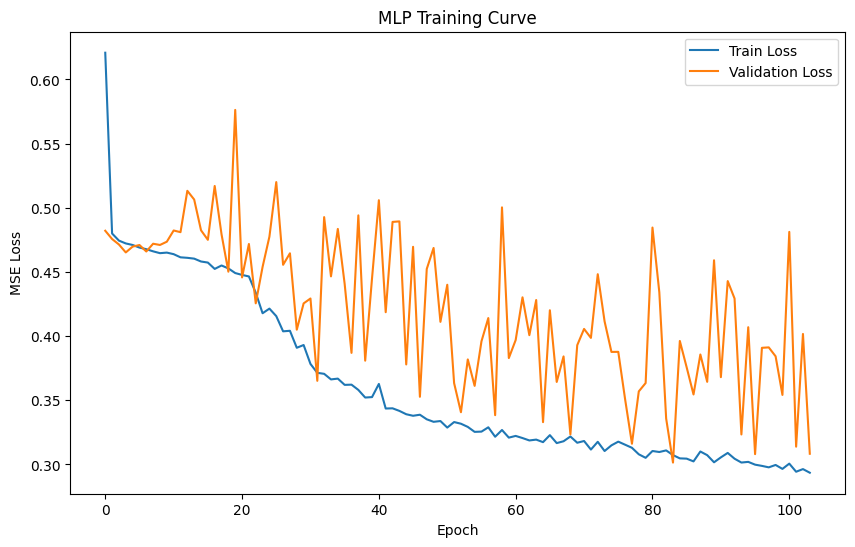

=== MLP Done ===


,Model,Seed,r2_log,mae_log,rmse_log,r2_orig,mae_orig,rmse_orig
0,Ridge,7,0.445460,0.378875,0.499187,0.306852,1.964900,4.352584
1,RandomForest,7,0.395590,0.393842,0.521150,0.227706,2.040708,4.594365
2,XGBoost,7,0.459697,0.374491,0.492738,0.290719,1.939276,4.402944
3,MLP,7,0.329066,0.409605,0.549082,0.129974,2.128479,4.876409


SEED: 42
=== Ridge Done ===
=== Random Forest Done ===
=== XGBoost Done ===

Early stopping at epoch 59


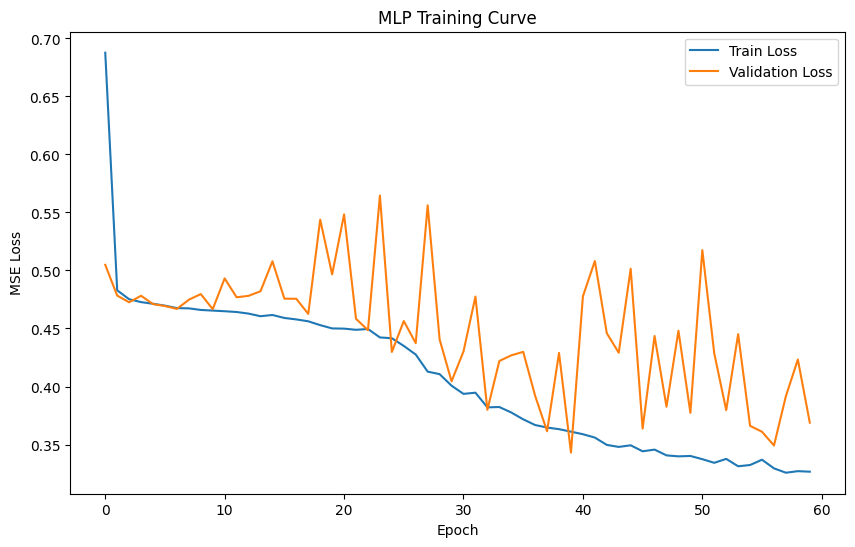

=== MLP Done ===


,Model,Seed,r2_log,mae_log,rmse_log,r2_orig,mae_orig,rmse_orig
0,Ridge,42,0.460859,0.378304,0.492160,0.355729,1.931930,4.023732
1,RandomForest,42,0.404839,0.392645,0.517097,0.265232,2.003893,4.297043
2,XGBoost,42,0.479802,0.371182,0.483436,0.337839,1.894465,4.079213
3,MLP,42,0.266124,0.443600,0.574204,0.098647,2.228744,4.759289


SEED: 12
=== Ridge Done ===
=== Random Forest Done ===
=== XGBoost Done ===

Early stopping at epoch 70


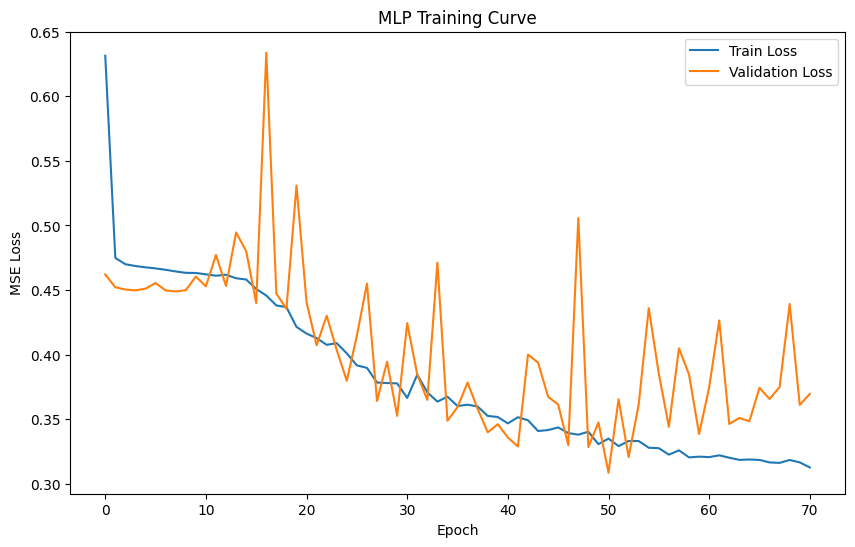

=== MLP Done ===


,Model,Seed,r2_log,mae_log,rmse_log,r2_orig,mae_orig,rmse_orig
0,Ridge,12,0.446509,0.380901,0.499119,0.260382,1.971990,4.342409
1,RandomForest,12,0.389447,0.396819,0.524217,0.241159,2.035470,4.398479
2,XGBoost,12,0.455198,0.378352,0.495186,0.308836,1.937814,4.197760
3,MLP,12,0.306112,0.418703,0.558848,0.113372,2.150270,4.754421


SEED: 52
=== Ridge Done ===
=== Random Forest Done ===
=== XGBoost Done ===

Early stopping at epoch 83


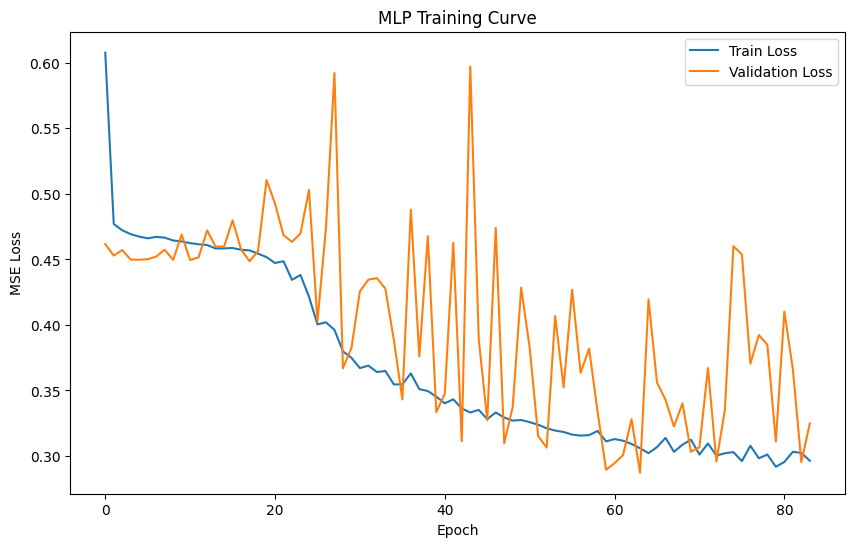

=== MLP Done ===


,Model,Seed,r2_log,mae_log,rmse_log,r2_orig,mae_orig,rmse_orig
0,Ridge,52,0.455693,0.380959,0.502118,0.311029,2.024193,4.515437
1,RandomForest,52,0.408797,0.395146,0.523301,0.236900,2.090553,4.752148
2,XGBoost,52,0.471151,0.376027,0.494936,0.300408,1.993400,4.550108
3,MLP,52,0.384545,0.412695,0.533927,0.217152,2.159027,4.813244


SEED: 87
=== Ridge Done ===
=== Random Forest Done ===
=== XGBoost Done ===

Early stopping at epoch 85


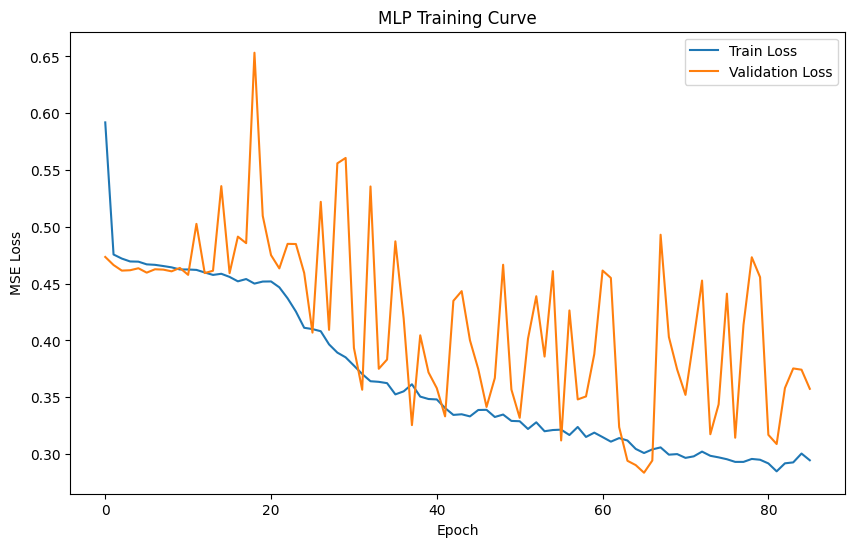

=== MLP Done ===


,Model,Seed,r2_log,mae_log,rmse_log,r2_orig,mae_orig,rmse_orig
0,Ridge,87,0.454616,0.378548,0.494366,0.331020,1.962386,4.178745
1,RandomForest,87,0.403661,0.391227,0.516945,0.251194,2.020152,4.421035
2,XGBoost,87,0.469979,0.372594,0.487354,0.322477,1.921905,4.205340
3,MLP,87,0.386798,0.398798,0.524203,0.219395,2.053504,4.513929


Seed               r2_log             mae_log            \
              mean        std      mean       std      mean       std   
Model                                                                   
MLP           40.0  32.519225  0.334529  0.051842  0.416680  0.016692   
RandomForest  40.0  32.519225  0.400467  0.007809  0.393936  0.002167   
Ridge         40.0  32.519225  0.452627  0.006518  0.379517  0.001306   
XGBoost       40.0  32.519225  0.467165  0.009779  0.374529  0.002820   

              rmse_log             r2_orig            mae_orig            \
                  mean       std      mean       std      mean       std   
Model                                                                      
MLP           0.548053  0.019811  0.155708  0.058185  2.144005  0.063002   
RandomForest  0.520542  0.003402  0.244438  0.014366  2.038155  0.032624   
Ridge         0.497390  0.004033  0.313002  0.035216  1.971080  0.033423   
XGBoost       0.490730  0.005152  0.312056  0.018538  1.937372  0.036136   

             rmse_orig            
                  mean       std  
Model                             
MLP           4.743458  0.137478  
RandomForest  4.492614  0.180239  
Ridge         4.282581  0.187408  
XGBoost       4.287073  0.187401

In [ ]:
all_results = []
for seed in SEEDS:

    print("=" * 50)
    print(f"SEED: {seed}")
    print("=" * 50)

    split_df = create_patient_stratified_masks_from_dataframe(
        final_df.copy(),
        seed=seed
    )

    train_df = split_df[
        split_df["split"] == "train"
    ]

    val_df = split_df[
        split_df["split"] == "val"
    ]

    test_df = split_df[
        split_df["split"] == "test"
    ]

    X_train = train_df[FEATURE_COLS].values
    X_val = val_df[FEATURE_COLS].values
    X_test = test_df[FEATURE_COLS].values

    y_train = train_df["log_y"].values
    y_val = val_df["log_y"].values
    y_test = test_df["log_y"].values


    ridge = Ridge(alpha=1.0)

    ridge.fit(X_train, y_train)

    ridge_test_pred = ridge.predict(X_test)

    ridge_metrics = compute_metrics(
        y_test,
        ridge_test_pred
    )

    print("=== Ridge Done ===")

    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        n_jobs=-1,
        random_state=seed
    )

    rf.fit(X_train, y_train)

    rf_test_pred = rf.predict(X_test)

    rf_metrics = compute_metrics(
        y_test,
        rf_test_pred
    )

    print("=== Random Forest Done ===")

    xgb = XGBRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        tree_method="hist"
    )

    xgb.fit(X_train, y_train)

    xgb_test_pred = xgb.predict(X_test)

    xgb_metrics = compute_metrics(
        y_test,
        xgb_test_pred
    )

    print("=== XGBoost Done ===")

    mlp_metrics = run_mlp(X_train, y_train, X_val, y_val, X_test, y_test, batch_size = 2048, epochs = 150)

    print("=== MLP Done ===")


    seed_results = pd.DataFrame([
        ["Ridge", seed, *ridge_metrics.values()],
        ["RandomForest", seed, *rf_metrics.values()],
        ["XGBoost", seed, *xgb_metrics.values()],
        ["MLP", seed, *mlp_metrics.values()],
    ], columns=[
        "Model",
        "Seed",
        *ridge_metrics.keys()
    ])

    display(seed_results)
    results_dir = f'/content/drive/MyDrive/Thesis/Results/CCI Removed/Seed_{seed}/'
    seed_results.to_csv(f'{results_dir}/baseline_ablation.csv')

    all_results.append(seed_results)


all_results = pd.concat(
    all_results,
    ignore_index=True
)

summary_results = (
    all_results
    .groupby("Model")
    .agg(["mean", "std"])
)

display(summary_results)

In [ ]:
results_dir = f'/content/drive/MyDrive/Thesis/Results/CCI Removed'
summary_results.to_csv(f'{results_dir}/baseline_ablation_results_summary.csv')

## GNN Ablation

In [11]:
# Additional configurations were added for the ablation study.

class EdgeDominantHeteroGNN(nn.Module):

    def __init__(
        self,
        data,
        metadata,
        hidden_channels=64,
        out_channels=1,
        conv_layer=GATv2Conv,
        dropout=0.3,
        heads=2,
        edge_dropout=0.10,
        edge_residual_weight=0.5,
        mode="dual",
        use_edge_attr=True,
        use_edge_residual=True,
        use_raw_head=True,
        active_relations=None,
    ):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.dropout = nn.Dropout(dropout)
        self.conv_layer = conv_layer
        self.edge_dropout = edge_dropout
        self.edge_residual_weight = edge_residual_weight
        self.mode = mode

        self.use_edge_attr = use_edge_attr
        self.use_edge_residual = use_edge_residual
        self.use_raw_head = use_raw_head
        self.active_relations = set(active_relations) if active_relations is not None else None

        self.metadata = metadata

        def et_key(et):
            return "__".join(et)

        self.et_key = et_key

        self.lin_dict = nn.ModuleDict()
        self.res_lin_dict = nn.ModuleDict()
        self.norms = nn.ModuleDict()
        self.embeddings = nn.ModuleDict()

        self.edge_dims = {}
        self.edge_encoder = nn.ModuleDict()
        self.edge_gate = nn.ModuleDict()
        self.edge_norm = nn.ModuleDict()
        self.edge_to_node = nn.ModuleDict()
        self.rel_scale = nn.ParameterDict()

        for ntype in metadata[0]:
            if getattr(data[ntype], "x", None) is not None:
                in_channels = data[ntype].x.size(1)

                self.lin_dict[ntype] = nn.Linear(in_channels, hidden_channels)
                self.res_lin_dict[ntype] = nn.Linear(in_channels, hidden_channels)
                self.norms[ntype] = GraphNorm(hidden_channels)
            else:
                print(f"{ntype}: using embedding")
                self.embeddings[ntype] = nn.Embedding(
                    data[ntype].num_nodes,
                    hidden_channels
                )
                self.norms[ntype] = nn.Identity()


        for et in metadata[1]:
            key = et_key(et)

            if hasattr(data[et], "edge_attr") and data[et].edge_attr is not None:
                edge_dim = data[et].edge_attr.size(1)
                self.edge_dims[et] = edge_dim

                self.edge_encoder[key] = nn.Sequential(
                    nn.Linear(edge_dim, hidden_channels),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_channels, hidden_channels),
                )

                self.edge_gate[key] = nn.Sequential(
                    nn.Linear(edge_dim, hidden_channels),
                    nn.Sigmoid(),
                )

                self.edge_norm[key] = nn.LayerNorm(hidden_channels)
                self.edge_to_node[key] = nn.Linear(hidden_channels, hidden_channels)
                self.rel_scale[key] = nn.Parameter(torch.tensor(1.0))
            else:
                self.edge_dims[et] = None
                print(f"{et}: NO edge_attr")


        def build_conv():
            convs = {}

            for et in metadata[1]:
                if self.edge_dims[et] is not None:
                    convs[et] = conv_layer(
                        (-1, -1),
                        hidden_channels,
                        heads=heads,
                        concat=False,
                        add_self_loops=False,
                        edge_dim=hidden_channels,
                    )
                else:
                    convs[et] = conv_layer(
                        (-1, -1),
                        hidden_channels,
                        heads=heads,
                        concat=False,
                        add_self_loops=False,
                    )

            return HeteroConv(convs, aggr="sum")

        self.conv1 = build_conv()
        self.conv2 = build_conv()


        self.log_head = nn.Linear(hidden_channels, out_channels)
        self.raw_head = nn.Linear(hidden_channels, out_channels)


    def filter_relations(self, edge_index_dict, edge_attr_dict=None):
        if self.active_relations is None:
            return edge_index_dict, edge_attr_dict

        edge_index_new = {}
        edge_attr_new = {} if edge_attr_dict is not None else None

        for et, edge_index in edge_index_dict.items():
            if et not in self.active_relations:
                continue

            edge_index_new[et] = edge_index

            if edge_attr_new is not None:
                edge_attr_new[et] = edge_attr_dict.get(et, None)

        return edge_index_new, edge_attr_new


    def encode_edges(self, edge_index_dict, edge_attr_dict):
        edge_index_new = {}
        edge_attr_encoded = {}

        for et, edge_index in edge_index_dict.items():
            key = self.et_key(et)

            if not self.use_edge_attr:
                edge_index_new[et] = edge_index
                edge_attr_encoded[et] = None
                continue

            has_attr = (
                edge_attr_dict is not None
                and et in edge_attr_dict
                and edge_attr_dict[et] is not None
                and self.edge_dims.get(et) is not None
            )

            if has_attr:
                edge_attr = edge_attr_dict[et]

                assert edge_attr.dim() == 2, f"{et} edge_attr must be 2D"
                assert edge_attr.size(0) == edge_index.size(1), (
                    f"{et} mismatch: edge_index has {edge_index.size(1)} edges, "
                    f"edge_attr has {edge_attr.size(0)} rows"
                )

                if self.training and self.edge_dropout > 0:
                    keep = torch.rand(
                        edge_attr.size(0),
                        device=edge_attr.device
                    ) > self.edge_dropout

                    edge_index = edge_index[:, keep]
                    edge_attr = edge_attr[keep]

                edge_h = self.edge_encoder[key](edge_attr)
                gate = self.edge_gate[key](edge_attr)

                edge_h = edge_h * gate
                edge_h = self.edge_norm[key](edge_h)
                edge_h = edge_h * self.rel_scale[key]

                edge_index_new[et] = edge_index
                edge_attr_encoded[et] = edge_h

            else:
                edge_index_new[et] = edge_index
                edge_attr_encoded[et] = None

        return edge_index_new, edge_attr_encoded


    def add_edge_residual(self, x_dict, edge_index_dict, edge_attr_encoded):
        if not self.use_edge_residual:
            return x_dict

        out = dict(x_dict)

        for et, edge_h in edge_attr_encoded.items():
            if edge_h is None:
                continue

            src, rel, dst = et
            key = self.et_key(et)

            if et not in edge_index_dict:
                continue

            dst_index = edge_index_dict[et][1]

            edge_summary = scatter(
                edge_h,
                dst_index,
                dim=0,
                dim_size=out[dst].size(0),
                reduce="mean",
            )

            edge_summary = self.edge_to_node[key](edge_summary)
            out[dst] = out[dst] + self.edge_residual_weight * edge_summary

        return out


    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None, batch_dict=None):
        device = next(self.parameters()).device


        x_processed = {}

        for ntype in x_dict:
            x = x_dict[ntype]

            if x is None:
                x = self.embeddings[ntype](
                    torch.arange(
                        self.embeddings[ntype].num_embeddings,
                        device=device,
                    )
                )
            else:
                h = self.lin_dict[ntype](x)
                res = self.res_lin_dict[ntype](x)
                x = F.relu(h + res)

            norm = self.norms[ntype]

            if isinstance(norm, GraphNorm) and batch_dict is not None and ntype in batch_dict:
                x = norm(x, batch_dict[ntype])
            else:
                x = norm(x)

            x_processed[ntype] = self.dropout(x)


        edge_index_filtered, edge_attr_filtered = self.filter_relations(
            edge_index_dict,
            edge_attr_dict,
        )


        edge_index_used, edge_attr_encoded = self.encode_edges(
            edge_index_filtered,
            edge_attr_filtered,
        )

        out_conv1 = self.conv1(
            x_processed,
            edge_index_used,
            edge_attr_dict=edge_attr_encoded,
        )

        x_current = {}
        for ntype in x_processed:
            h = out_conv1.get(ntype, x_processed[ntype])
            h = h + x_processed[ntype]
            x_current[ntype] = self.dropout(F.relu(h))

        x_current = self.add_edge_residual(
            x_current,
            edge_index_used,
            edge_attr_encoded,
        )


        out_conv2 = self.conv2(
            x_current,
            edge_index_used,
            edge_attr_dict=edge_attr_encoded,
        )

        x_final = {}
        for ntype in x_processed:
            h = out_conv2.get(ntype, x_current[ntype])
            h = h + x_current[ntype]
            h = h + x_processed[ntype]
            x_final[ntype] = self.dropout(F.relu(h))

        x_final = self.add_edge_residual(
            x_final,
            edge_index_used,
            edge_attr_encoded,
        )

        h = x_final["stay"]

        log_pred = self.log_head(h)

        log_pred_clamped = torch.clamp(log_pred, min=0.0, max=5.0)
        base_raw = torch.expm1(log_pred_clamped)

        if self.use_raw_head:
            residual = 0.5 * self.raw_head(h)
            raw_pred = torch.relu(base_raw + residual)
        else:
            raw_pred = base_raw

        return log_pred, raw_pred

### Models Ablation

In [17]:
epochs = 150
patience = 50

for seed in SEEDS:
  print(f"Results with seed: {seed}")
  data = create_patient_stratified_masks(data, seed=seed)
  data_undirect = ToUndirected()(data)
  models = {
      'Full': EdgeDominantHeteroGNN(
          data=data_undirect,
          metadata=data_undirect.metadata(),
          hidden_channels=hyperparameters['hidden_channels'],
          out_channels=1,
          dropout=hyperparameters['dropout'],
          heads=hyperparameters['heads'],
          edge_dropout=hyperparameters['edge_dropout'],
          edge_residual_weight=hyperparameters['edge_residual_weight']
      ),

      'Without edge attributes': EdgeDominantHeteroGNN(
          data_undirect,
          data_undirect.metadata(),
          hidden_channels=hyperparameters['hidden_channels'],
          out_channels=1,
          dropout=hyperparameters['dropout'],
          heads=hyperparameters['heads'],
          edge_dropout=hyperparameters['edge_dropout'],
          edge_residual_weight=hyperparameters['edge_residual_weight'],
          use_edge_attr=False,
      ),

      'Without edge-to-node residual': EdgeDominantHeteroGNN(
          data_undirect,
          data_undirect.metadata(),
          hidden_channels=hyperparameters['hidden_channels'],
          out_channels=1,
          dropout=hyperparameters['dropout'],
          heads=hyperparameters['heads'],
          edge_dropout=hyperparameters['edge_dropout'],
          edge_residual_weight=hyperparameters['edge_residual_weight'],
          use_edge_residual=False,
      ),

      'Without raw prediction branch': EdgeDominantHeteroGNN(
          data_undirect,
          data_undirect.metadata(),
          hidden_channels=hyperparameters['hidden_channels'],
          out_channels=1,
          dropout=hyperparameters['dropout'],
          heads=hyperparameters['heads'],
          edge_dropout=hyperparameters['edge_dropout'],
          edge_residual_weight=hyperparameters['edge_residual_weight'],
          use_raw_head=False,
      ),
  }


  device = 'cuda' if torch.cuda.is_available() else 'cpu'

  results_dir = f'/content/drive/MyDrive/Thesis/Results/CCI Removed/Seed_{seed}/Graph Ablation'


  for model_name, model in models.items():
    train_loader, val_loader, test_loader = make_transductive_loaders(
        data_undirect,
        fanouts=fanouts,
        batch_size=batch_size)

    print(model_name)
    start_epoch = 0

    model_dir = f'{results_dir}/{model_name}'
    os.makedirs(model_dir, exist_ok=True)

    model = model.to(device)
    loss_fn =  DualLoss().to(device)

    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(loss_fn.parameters()),
        lr=hyperparameters['lr'])
    torch.cuda.empty_cache()

    train_losses, val_losses, val_r2_scores, val_r2_orig_scores, best_val_loss, val_mae_scores, val_mse_scores, val_rmse_log_scores, val_msle_scores, val_mad_scores, val_lmape_scores, val_kappa_scores, val_mae_orig_scores, val_rmse_orig_scores, val_kappa_binary_scores, best_path = train_loop(model, train_loader, val_loader,
                      optimizer, loss_fn, epochs,
                      patience, f'{model_dir}',
                      device, plot_rate=epochs ,start_epoch= start_epoch)

    checkpoint = torch.load(best_path, map_location=device)
    print(f"\nLoaded best model from epoch {checkpoint['epoch']}")

    model.load_state_dict(checkpoint['model_state_dict'])

    (test_loss,
          r2,
          test_r2_orig_scores,
          mae_log,
          mse_log,
          rmse_log,
          msle_val,
          mad_val,
          lmape,
          kappa,
          mae_orig,
          rmse_orig,
          kappa_binary,
          preds,
          targets) = evaluate(model, test_loader, loss_fn, device)

    print(f"Test Loss ON {model_name}: {test_loss:.4f} | "
        f"R2: {r2:.4f} | "
        f"R2(Orig): {test_r2_orig_scores:.4f} | "
        f"MAE (log): {mae_log:.4f} | "
        f"MSE (log): {mse_log:.4f} | "
        f"RMSE (log): {rmse_log:.4f} | "
        f"MSLE: {msle_val:.4f} | "
        f"MAD: {mad_val:.4f} | "
        f"LMAPE: {lmape:.4f} | "
        f"Kappa: {kappa:.4f} | "
        f"MAE (orig): {mae_orig:.4f} | "
        f"RMSE (orig): {rmse_orig:.4f} | "
        f"Kappa (binary): {kappa_binary:.4f}")

    test_history = {
          'test_loss': test_loss,
          'r2': r2,
          'r2_orig': test_r2_orig_scores,
          'mae_log': mae_log,
          'mse_log': mse_log,
          'rmse_log': rmse_log,
          'msle_val': msle_val,
          'mad_val': mad_val,
          'lmape': lmape,
          'kappa': kappa,
          'mae_orig': mae_orig,
          'rmse_orig': rmse_orig,
          'kappa_binary': kappa_binary,
          'preds': preds,
          'targets': targets,

      }

    with open(f'{model_dir}/test_results.pkl', 'wb') as f:
          pickle.dump(test_history, f)

Results with seed: 7
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422
Full
Epoch 1 | Train Loss: 30.4584 | Val Loss: 1.9142 | R2(log): -1.5514 | R2(orig): -1.6081 | MAE(log): 0.7938 | RMSE(log): 1.0788 | MAE(orig): 3.2823 | RMSE(orig): 8.5685 | Kappa(binary): 0.0803
✓ Best model updated
Epoch 2 | Train Loss: 12.2479 | Val Loss: 1.4403 | R2(log): -0.7142 | R2(orig): -1.0853 | MAE(log): 0.6440 | RMSE(log): 0.8842 | MAE(orig): 3.2288 | RMSE(orig): 7.6617 | Kappa(binary): 0.0897
✓ Best model updated
Epoch 3 | Train Loss: 6.2673 | Val Loss: 2.7207 | R2(log): -3.1029 | R2(orig): -0.6580 | MAE(log): 1.1860 | RMSE(log): 1.3680 | MAE(orig): 3.6379 | RMSE(orig): 6.8317 | Kappa(binary): 0.0088
✓ Best model updated
Epoch 4 | Train Loss: 3.6886 | Val Loss: 1.1568 | R2(log): -0.1695 | R2(orig): -0.5092 | MAE(log): 0.5265 | RMSE(log): 0.7304 | MAE(orig): 2.8794 | RMSE(orig): 6.5181 | Kappa(binary): 0.1124
✓ Best model updated
Epoch 5 | Train Loss: 2.0010 | Val Loss: 1.


Loaded best model from epoch 149
Test Loss ON Full: -0.0932 | R2: 0.5171 | R2(Orig): 0.3813 | MAE (log): 0.3639 | MSE (log): 0.2199 | RMSE (log): 0.4690 | MSLE: 0.2297 | MAD: 1.1211 | LMAPE: 48.8614 | Kappa: 0.4598 | MAE (orig): 2.0402 | RMSE (orig): 4.4076 | Kappa (binary): 0.4524
Without edge attributes
Epoch 1 | Train Loss: 13.3470 | Val Loss: 2.4343 | R2(log): -1.5802 | R2(orig): -2.7022 | MAE(log): 0.8814 | RMSE(log): 1.0848 | MAE(orig): 5.6403 | RMSE(orig): 10.2088 | Kappa(binary): 0.0658
✓ Best model updated
Epoch 2 | Train Loss: 10.8286 | Val Loss: 1.6512 | R2(log): -1.5844 | R2(orig): -0.2792 | MAE(log): 0.8533 | RMSE(log): 1.0857 | MAE(orig): 3.0945 | RMSE(orig): 6.0009 | Kappa(binary): 0.0203
✓ Best model updated
Epoch 3 | Train Loss: 2.4779 | Val Loss: 1.2505 | R2(log): -0.6212 | R2(orig): -0.1803 | MAE(log): 0.6410 | RMSE(log): 0.8599 | MAE(orig): 2.7898 | RMSE(orig): 5.7642 | Kappa(binary): 0.0491
✓ Best model updated
Epoch 4 | Train Loss: 5.2841 | Val Loss: 1.4219 | R2(


Loaded best model from epoch 148
Test Loss ON Without edge attributes: -0.0381 | R2: 0.4166 | R2(Orig): 0.2609 | MAE (log): 0.3861 | MSE (log): 0.2657 | RMSE (log): 0.5154 | MSLE: 0.2644 | MAD: 0.9501 | LMAPE: 58.3560 | Kappa: 0.4158 | MAE (orig): 2.0452 | RMSE (orig): 4.8172 | Kappa (binary): 0.4689
Without edge-to-node residual
Epoch 1 | Train Loss: 4.9322 | Val Loss: 1.7885 | R2(log): -1.3194 | R2(orig): -0.7009 | MAE(log): 0.7862 | RMSE(log): 1.0286 | MAE(orig): 3.1649 | RMSE(orig): 6.9196 | Kappa(binary): 0.0465
✓ Best model updated
Epoch 2 | Train Loss: 2.5998 | Val Loss: 1.8198 | R2(log): -1.4409 | R2(orig): -0.6506 | MAE(log): 0.8345 | RMSE(log): 1.0552 | MAE(orig): 3.2287 | RMSE(orig): 6.8166 | Kappa(binary): 0.0129
✓ Best model updated
Epoch 3 | Train Loss: 1.9584 | Val Loss: 1.5262 | R2(log): -0.9172 | R2(orig): -0.6066 | MAE(log): 0.7163 | RMSE(log): 0.9352 | MAE(orig): 3.0157 | RMSE(orig): 6.7252 | Kappa(binary): 0.0225
✓ Best model updated
Epoch 4 | Train Loss: 1.6730 | 


Loaded best model from epoch 138
Test Loss ON Without edge-to-node residual: -0.7837 | R2: 0.6205 | R2(Orig): 0.4014 | MAE (log): 0.2956 | MSE (log): 0.1728 | RMSE (log): 0.4157 | MSLE: 0.1762 | MAD: 0.7236 | LMAPE: 33.9440 | Kappa: 0.5253 | MAE (orig): 1.7688 | RMSE (orig): 4.3353 | Kappa (binary): 0.5508
Without raw prediction branch
Epoch 1 | Train Loss: 3.8176 | Val Loss: 0.8254 | R2(log): 0.1064 | R2(orig): -0.3063 | MAE(log): 0.4866 | RMSE(log): 0.6384 | MAE(orig): 2.5916 | RMSE(orig): 6.0640 | Kappa(binary): 0.2538
✓ Best model updated
Epoch 2 | Train Loss: 2.0637 | Val Loss: 0.9948 | R2(log): -0.1543 | R2(orig): -0.1069 | MAE(log): 0.5042 | RMSE(log): 0.7256 | MAE(orig): 2.4592 | RMSE(orig): 5.5822 | Kappa(binary): 0.0847
✓ Best model updated
Epoch 3 | Train Loss: 1.2070 | Val Loss: 0.7102 | R2(log): 0.2646 | R2(orig): 0.1089 | MAE(log): 0.4535 | RMSE(log): 0.5792 | MAE(orig): 2.3569 | RMSE(orig): 5.0085 | Kappa(binary): 0.3245
✓ Best model updated
Epoch 4 | Train Loss: 1.7272


Loaded best model from epoch 148
Test Loss ON Without raw prediction branch: -0.8232 | R2: 0.6089 | R2(Orig): 0.4295 | MAE (log): 0.3138 | MSE (log): 0.1781 | RMSE (log): 0.4220 | MSLE: 0.1781 | MAD: 0.8082 | LMAPE: 35.5346 | Kappa: 0.5356 | MAE (orig): 1.7879 | RMSE (orig): 4.2323 | Kappa (binary): 0.5539
Results with seed: 42
Total stays: 94441
Training stays: 75454
Validation stays: 9517
Test stays: 9470
Full
Epoch 1 | Train Loss: 2.8109 | Val Loss: 0.9724 | R2(log): -0.0097 | R2(orig): -0.4348 | MAE(log): 0.5440 | RMSE(log): 0.6808 | MAE(orig): 2.9891 | RMSE(orig): 6.4728 | Kappa(binary): 0.2733
✓ Best model updated
Epoch 2 | Train Loss: 1.4076 | Val Loss: 0.7119 | R2(log): 0.2996 | R2(orig): -0.0943 | MAE(log): 0.4022 | RMSE(log): 0.5670 | MAE(orig): 2.3121 | RMSE(orig): 5.6528 | Kappa(binary): 0.3921
✓ Best model updated
Epoch 3 | Train Loss: 1.0139 | Val Loss: 0.6744 | R2(log): 0.3489 | R2(orig): 0.0670 | MAE(log): 0.3822 | RMSE(log): 0.5467 | MAE(orig): 2.2100 | RMSE(orig): 5.

...


Loaded best model from epoch 147
Test Loss ON Without raw prediction branch: -0.4848 | R2: 0.5778 | R2(Orig): 0.4090 | MAE (log): 0.3274 | MSE (log): 0.1878 | RMSE (log): 0.4334 | MSLE: 0.1878 | MAD: 0.8487 | LMAPE: 34.5417 | Kappa: 0.5001 | MAE (orig): 1.8070 | RMSE (orig): 3.9553 | Kappa (binary): 0.5263
Results with seed: 87
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362
Full
Epoch 1 | Train Loss: 3.8723 | Val Loss: 0.9161 | R2(log): 0.0430 | R2(orig): -0.0202 | MAE(log): 0.5032 | RMSE(log): 0.6616 | MAE(orig): 2.5661 | RMSE(orig): 5.4790 | Kappa(binary): 0.2534
✓ Best model updated
Epoch 2 | Train Loss: 1.6904 | Val Loss: 0.7896 | R2(log): 0.1808 | R2(orig): 0.0730 | MAE(log): 0.4774 | RMSE(log): 0.6121 | MAE(orig): 2.4711 | RMSE(orig): 5.2228 | Kappa(binary): 0.3324
✓ Best model updated
Epoch 3 | Train Loss: 1.1905 | Val Loss: 0.7282 | R2(log): 0.3132 | R2(orig): 0.0906 | MAE(log): 0.4043 | RMSE(log): 0.5605 | MAE(orig): 2.2279 | RMSE(orig): 5.17


Loaded best model from epoch 146
Test Loss ON Full: -0.7593 | R2: 0.6110 | R2(Orig): 0.4429 | MAE (log): 0.3182 | MSE (log): 0.1787 | RMSE (log): 0.4227 | MSLE: 0.1883 | MAD: 0.9343 | LMAPE: 42.8082 | Kappa: 0.5245 | MAE (orig): 1.8791 | RMSE (orig): 4.0270 | Kappa (binary): 0.5269
Without edge attributes
Epoch 1 | Train Loss: 36.2640 | Val Loss: 2.9361 | R2(log): -4.3914 | R2(orig): -0.6400 | MAE(log): 1.3259 | RMSE(log): 1.5703 | MAE(orig): 3.5827 | RMSE(orig): 6.9469 | Kappa(binary): 0.0102
✓ Best model updated
Epoch 2 | Train Loss: 9.5074 | Val Loss: 2.6755 | R2(log): -3.5513 | R2(orig): -0.6246 | MAE(log): 1.2037 | RMSE(log): 1.4428 | MAE(orig): 3.5850 | RMSE(orig): 6.9141 | Kappa(binary): 0.0062
✓ Best model updated
Epoch 3 | Train Loss: 4.5556 | Val Loss: 1.8273 | R2(log): -1.6405 | R2(orig): -0.5738 | MAE(log): 0.8403 | RMSE(log): 1.0990 | MAE(orig): 3.3681 | RMSE(orig): 6.8052 | Kappa(binary): 0.0072
✓ Best model updated
Epoch 4 | Train Loss: 2.9579 | Val Loss: 1.9260 | R2(lo


Loaded best model from epoch 127
Test Loss ON Without edge attributes: 0.2597 | R2: 0.3758 | R2(Orig): 0.2204 | MAE (log): 0.3960 | MSE (log): 0.2867 | RMSE (log): 0.5354 | MSLE: 0.2730 | MAD: 0.8968 | LMAPE: 64.0331 | Kappa: 0.3770 | MAE (orig): 2.0617 | RMSE (orig): 4.7635 | Kappa (binary): 0.4566
Without edge-to-node residual
Epoch 1 | Train Loss: 7.5418 | Val Loss: 1.9038 | R2(log): -1.6068 | R2(orig): -1.5406 | MAE(log): 0.7757 | RMSE(log): 1.0919 | MAE(orig): 3.2688 | RMSE(orig): 8.6463 | Kappa(binary): 0.0458
✓ Best model updated
Epoch 2 | Train Loss: 3.0850 | Val Loss: 1.6195 | R2(log): -0.9966 | R2(orig): -1.0958 | MAE(log): 0.7024 | RMSE(log): 0.9556 | MAE(orig): 3.1315 | RMSE(orig): 7.8531 | Kappa(binary): 0.0386
✓ Best model updated
Epoch 3 | Train Loss: 2.3175 | Val Loss: 1.5319 | R2(log): -0.8359 | R2(orig): -0.5762 | MAE(log): 0.6876 | RMSE(log): 0.9163 | MAE(orig): 2.9919 | RMSE(orig): 6.8105 | Kappa(binary): 0.0279
✓ Best model updated
Epoch 4 | Train Loss: 1.9655 | V


Loaded best model from epoch 138
Test Loss ON Without edge-to-node residual: -0.7076 | R2: 0.6345 | R2(Orig): 0.4176 | MAE (log): 0.2940 | MSE (log): 0.1679 | RMSE (log): 0.4098 | MSLE: 0.1733 | MAD: 0.7762 | LMAPE: 37.8815 | Kappa: 0.5197 | MAE (orig): 1.7696 | RMSE (orig): 4.1174 | Kappa (binary): 0.5401
Without raw prediction branch
Epoch 1 | Train Loss: 15.2077 | Val Loss: 11.5859 | R2(log): -24.7101 | R2(orig): -0.9063 | MAE(log): 3.2739 | RMSE(log): 3.4292 | MAE(orig): 3.7338 | RMSE(orig): 7.4897 | Kappa(binary): 0.0028
✓ Best model updated
Epoch 2 | Train Loss: 12.4553 | Val Loss: 2.5474 | R2(log): -3.9240 | R2(orig): -1.4132 | MAE(log): 1.3238 | RMSE(log): 1.5007 | MAE(orig): 3.6967 | RMSE(orig): 8.4269 | Kappa(binary): 0.1961
No improvement (1/50)
Epoch 3 | Train Loss: 4.5756 | Val Loss: 3.7446 | R2(log): -8.0065 | R2(orig): -0.6235 | MAE(log): 1.8084 | RMSE(log): 2.0296 | MAE(orig): 3.3179 | RMSE(orig): 6.9119 | Kappa(binary): 0.1998
✓ Best model updated
Epoch 4 | Train Loss


Loaded best model from epoch 148
Test Loss ON Without raw prediction branch: -0.2504 | R2: 0.5195 | R2(Orig): 0.3940 | MAE (log): 0.3673 | MSE (log): 0.2207 | RMSE (log): 0.4698 | MSLE: 0.2207 | MAD: 1.0979 | LMAPE: 53.7528 | Kappa: 0.4749 | MAE (orig): 2.0140 | RMSE (orig): 4.2000 | Kappa (binary): 0.4725


### Single Edge Ablation

In [19]:
def remove_edges(data, edge_types_to_remove):
    data = data.clone()

    for et in edge_types_to_remove:
        src, rel, dst = et

        if et in data.edge_types:
            print(f"Removing edge: {et}")
            del data[et]

        rev_et = (dst, f"rev_{rel}", src)
        if rev_et in data.edge_types:
            print(f"Removing edge: {rev_et}")
            del data[rev_et]

    return data

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
for seed in SEEDS:
  print(f"Results with seed: {seed}")

  edge_ablation_configs = {
    # "Full": None,
    "Without HAS_DIAGNOSIS": [("stay", "HAS_DIAGNOSIS", "diagnosis")],
    "Without HAS_PROCEDURE": [("stay", "HAS_PROCEDURE", "procedure")],
    "Without HAS_CHART": [("stay", "HAS_CHARTED", "chart_numeric")],
    "Without HAS_INPUT": [("stay", "HAS_INPUT", "input")],
    "Without HAS_OUTPUT": [("stay", "HAS_OUTPUT", "output")],
  }
  results_dir = f'/content/drive/MyDrive/Thesis/Results/CCI Removed/Seed_{seed}/Edges Ablation'


  for model_name, edges_to_remove in edge_ablation_configs.items():
      data = create_patient_stratified_masks(data, seed=seed)
      data_undirect = ToUndirected()(data)

      print(f"\n===== {model_name} =====")
      epochs=150
      patience =50
      if edges_to_remove is None:
          data_variant = data_undirect
      else:
          data_variant = remove_edges(data_undirect, edges_to_remove)

      train_loader, val_loader, test_loader = make_transductive_loaders(
          data_variant,
          fanouts=fanouts,
          batch_size=batch_size,
          seed=12
      )

      model = EdgeDominantHeteroGNN(
          data=data_variant,
          metadata=data_variant.metadata(),
          hidden_channels=hyperparameters['hidden_channels'],
          out_channels=1,
          dropout=hyperparameters['dropout'],
          heads=hyperparameters['heads'],
          edge_dropout=hyperparameters['edge_dropout'],
          edge_residual_weight=hyperparameters['edge_residual_weight']
      ).to(device)

      loss_fn = DualLoss().to(device)

      optimizer = torch.optim.Adam(
          list(model.parameters()) + list(loss_fn.parameters()),
          lr=hyperparameters['lr']
      )

      model_dir = f'{results_dir}/{model_name}'
      os.makedirs(model_dir, exist_ok=True)

      torch.cuda.empty_cache()

      train_losses, val_losses, val_r2_scores, val_r2_orig_scores, best_val_loss, \
      val_mae_scores, val_mse_scores, val_rmse_log_scores, val_msle_scores, \
      val_mad_scores, val_lmape_scores, val_kappa_scores, val_mae_orig_scores, \
      val_rmse_orig_scores, val_kappa_binary_scores, best_path = train_loop(
          model,
          train_loader,
          val_loader,
          optimizer,
          loss_fn,
          epochs=epochs,
          patience=patience,
          model_dir=model_dir,
          device=device,
          plot_rate=epochs,
          start_epoch=0
      )

      checkpoint = torch.load(best_path, map_location=device)
      print(f"\nLoaded best model from epoch {checkpoint['epoch']}")
      model.load_state_dict(checkpoint['model_state_dict'])

      results = evaluate(model, test_loader, loss_fn, device)

      print(f"Test R2(log): {results[1]:.4f} | R2(orig): {results[2]:.4f}")

      with open(f'{model_dir}/test_results.pkl', 'wb') as f:
          pickle.dump(results, f)

Results with seed: 7
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422

===== Without HAS_DIAGNOSIS =====
Removing edge: ('stay', 'HAS_DIAGNOSIS', 'diagnosis')
Removing edge: ('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Epoch 1 | Train Loss: 22.0382 | Val Loss: 2.3531 | R2(log): -2.7710 | R2(orig): -0.3340 | MAE(log): 1.0506 | RMSE(log): 1.3115 | MAE(orig): 3.2684 | RMSE(orig): 6.1280 | Kappa(binary): 0.0373
✓ Best model updated
Epoch 2 | Train Loss: 12.4312 | Val Loss: 1.2462 | R2(log): -0.5714 | R2(orig): -0.3795 | MAE(log): 0.6687 | RMSE(log): 0.8466 | MAE(orig): 3.4994 | RMSE(orig): 6.2317 | Kappa(binary): 0.1508
No improvement (1/50)
Epoch 3 | Train Loss: 2.7008 | Val Loss: 0.9710 | R2(log): -0.1856 | R2(orig): 0.0099 | MAE(log): 0.5795 | RMSE(log): 0.7354 | MAE(orig): 2.8123 | RMSE(orig): 5.2794 | Kappa(binary): 0.1908
✓ Best model updated
Epoch 4 | Train Loss: 2.0100 | Val Loss: 0.9691 | R2(log): -0.1317 | R2(orig): -0.0880 | MAE(log): 0.4945 | RMSE(


Loaded best model from epoch 149
Test R2(log): 0.4627 | R2(orig): 0.2559
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422

===== Without HAS_PROCEDURE =====
Removing edge: ('stay', 'HAS_PROCEDURE', 'procedure')
Removing edge: ('procedure', 'rev_HAS_PROCEDURE', 'stay')
Epoch 1 | Train Loss: 27.5523 | Val Loss: 2.5180 | R2(log): -2.1661 | R2(orig): -3.1769 | MAE(log): 1.0099 | RMSE(log): 1.2017 | MAE(orig): 6.9087 | RMSE(orig): 10.8436 | Kappa(binary): 0.0226
✓ Best model updated
Epoch 2 | Train Loss: 5.3132 | Val Loss: 1.9437 | R2(log): -1.7234 | R2(orig): -0.2965 | MAE(log): 0.8918 | RMSE(log): 1.1146 | MAE(orig): 3.0667 | RMSE(orig): 6.0414 | Kappa(binary): 0.0308
✓ Best model updated
Epoch 3 | Train Loss: 2.4005 | Val Loss: 0.9265 | R2(log): -0.0316 | R2(orig): -0.3171 | MAE(log): 0.5430 | RMSE(log): 0.6860 | MAE(orig): 2.9036 | RMSE(orig): 6.0890 | Kappa(binary): 0.1973
No improvement (1/50)
Epoch 4 | Train Loss: 5.2721 | Val Loss: 1.2413 | R2(log): 


Loaded best model from epoch 143
Test R2(log): 0.5197 | R2(orig): 0.3793
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422

===== Without HAS_CHART =====
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Epoch 1 | Train Loss: 4.6784 | Val Loss: 1.4195 | R2(log): -0.8037 | R2(orig): -1.1313 | MAE(log): 0.6421 | RMSE(log): 0.9070 | MAE(orig): 3.1579 | RMSE(orig): 7.7458 | Kappa(binary): 0.1144
✓ Best model updated
Epoch 2 | Train Loss: 2.2562 | Val Loss: 0.8547 | R2(log): 0.0434 | R2(orig): 0.0162 | MAE(log): 0.4868 | RMSE(log): 0.6606 | MAE(orig): 2.5142 | RMSE(orig): 5.2625 | Kappa(binary): 0.2679
✓ Best model updated
Epoch 3 | Train Loss: 1.5559 | Val Loss: 0.8976 | R2(log): -0.0334 | R2(orig): -0.0256 | MAE(log): 0.4668 | RMSE(log): 0.6865 | MAE(orig): 2.3862 | RMSE(orig): 5.3732 | Kappa(binary): 0.2538
No improvement (1/50)
Epoch 4 | Train Loss: 1.2964 | Val Loss: 0.7962 | R2(log): 0.17


Loaded best model from epoch 148
Test R2(log): 0.5600 | R2(orig): 0.4124
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422

===== Without HAS_INPUT =====
Removing edge: ('stay', 'HAS_INPUT', 'input')
Removing edge: ('input', 'rev_HAS_INPUT', 'stay')
Epoch 1 | Train Loss: 4.6253 | Val Loss: 1.4412 | R2(log): -0.7985 | R2(orig): -0.5798 | MAE(log): 0.6629 | RMSE(log): 0.9057 | MAE(orig): 3.0081 | RMSE(orig): 6.6688 | Kappa(binary): 0.0593
✓ Best model updated
Epoch 2 | Train Loss: 3.1624 | Val Loss: 2.0786 | R2(log): -3.1539 | R2(orig): -0.2294 | MAE(log): 1.2014 | RMSE(log): 1.3765 | MAE(orig): 3.3958 | RMSE(orig): 5.8828 | Kappa(binary): 0.1920
✓ Best model updated
Epoch 3 | Train Loss: 3.0438 | Val Loss: 1.1171 | R2(log): -0.2155 | R2(orig): -0.1484 | MAE(log): 0.5245 | RMSE(log): 0.7446 | MAE(orig): 2.6011 | RMSE(orig): 5.6857 | Kappa(binary): 0.0532
✓ Best model updated
Epoch 4 | Train Loss: 1.2767 | Val Loss: 0.7239 | R2(log): 0.3050 | R2(orig): 0.08


Loaded best model from epoch 130
Test R2(log): 0.5828 | R2(orig): 0.4099
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422

===== Without HAS_OUTPUT =====
Removing edge: ('stay', 'HAS_OUTPUT', 'output')
Removing edge: ('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 5.5802 | Val Loss: 1.0663 | R2(log): -0.2213 | R2(orig): -0.8557 | MAE(log): 0.5640 | RMSE(log): 0.7464 | MAE(orig): 3.0073 | RMSE(orig): 7.2277 | Kappa(binary): 0.2272
✓ Best model updated
Epoch 2 | Train Loss: 5.6426 | Val Loss: 3.1353 | R2(log): -4.4236 | R2(orig): -0.4477 | MAE(log): 1.4496 | RMSE(log): 1.5728 | MAE(orig): 3.5980 | RMSE(orig): 6.3838 | Kappa(binary): 0.0013
✓ Best model updated
Epoch 3 | Train Loss: 2.9890 | Val Loss: 0.8146 | R2(log): 0.1887 | R2(orig): -0.0058 | MAE(log): 0.4485 | RMSE(log): 0.6083 | MAE(orig): 2.3738 | RMSE(orig): 5.3211 | Kappa(binary): 0.2331
✓ Best model updated
Epoch 4 | Train Loss: 1.7663 | Val Loss: 0.8004 | R2(log): 0.1702 | R2(orig): 

...


Loaded best model from epoch 143
Test R2(log): 0.4817 | R2(orig): 0.2835
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362

===== Without HAS_PROCEDURE =====
Removing edge: ('stay', 'HAS_PROCEDURE', 'procedure')
Removing edge: ('procedure', 'rev_HAS_PROCEDURE', 'stay')
Epoch 1 | Train Loss: 28.3087 | Val Loss: 2.3803 | R2(log): -2.6737 | R2(orig): -0.2915 | MAE(log): 1.0254 | RMSE(log): 1.2962 | MAE(orig): 3.1742 | RMSE(orig): 6.1647 | Kappa(binary): 0.0290
✓ Best model updated
Epoch 2 | Train Loss: 7.6245 | Val Loss: 1.1632 | R2(log): -0.4886 | R2(orig): -0.3232 | MAE(log): 0.6055 | RMSE(log): 0.8251 | MAE(orig): 3.0622 | RMSE(orig): 6.2399 | Kappa(binary): 0.2303
No improvement (1/50)
Epoch 3 | Train Loss: 9.5999 | Val Loss: 0.9123 | R2(log): -0.0195 | R2(orig): -0.0456 | MAE(log): 0.5116 | RMSE(log): 0.6828 | MAE(orig): 2.6538 | RMSE(orig): 5.5470 | Kappa(binary): 0.2378
✓ Best model updated
Epoch 4 | Train Loss: 8.6684 | Val Loss: 1.0840 | R2(log): -


Loaded best model from epoch 149
Test R2(log): 0.5575 | R2(orig): 0.3906
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362

===== Without HAS_CHART =====
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Epoch 1 | Train Loss: 4.3747 | Val Loss: 1.1566 | R2(log): -0.3051 | R2(orig): -0.4314 | MAE(log): 0.5559 | RMSE(log): 0.7726 | MAE(orig): 2.8971 | RMSE(orig): 6.4901 | Kappa(binary): 0.0961
✓ Best model updated
Epoch 2 | Train Loss: 2.2567 | Val Loss: 0.9105 | R2(log): 0.0482 | R2(orig): -0.0245 | MAE(log): 0.4843 | RMSE(log): 0.6598 | MAE(orig): 2.4787 | RMSE(orig): 5.4907 | Kappa(binary): 0.2081
✓ Best model updated
Epoch 3 | Train Loss: 1.6301 | Val Loss: 0.9448 | R2(log): -0.0049 | R2(orig): -0.0681 | MAE(log): 0.4680 | RMSE(log): 0.6779 | MAE(orig): 2.4337 | RMSE(orig): 5.6061 | Kappa(binary): 0.1147
No improvement (1/50)
Epoch 4 | Train Loss: 1.2013 | Val Loss: 0.8208 | R2(log): 0.1


Loaded best model from epoch 145
Test R2(log): 0.5753 | R2(orig): 0.4189
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362

===== Without HAS_INPUT =====
Removing edge: ('stay', 'HAS_INPUT', 'input')
Removing edge: ('input', 'rev_HAS_INPUT', 'stay')
Epoch 1 | Train Loss: 26.1145 | Val Loss: 5.1763 | R2(log): -7.6051 | R2(orig): -1.2642 | MAE(log): 1.8236 | RMSE(log): 1.9839 | MAE(orig): 3.8239 | RMSE(orig): 8.1625 | Kappa(binary): 0.0118
✓ Best model updated
Epoch 2 | Train Loss: 8.4160 | Val Loss: 1.2927 | R2(log): -0.5259 | R2(orig): -1.5100 | MAE(log): 0.6098 | RMSE(log): 0.8354 | MAE(orig): 3.2954 | RMSE(orig): 8.5942 | Kappa(binary): 0.1854
No improvement (1/50)
Epoch 3 | Train Loss: 5.0431 | Val Loss: 1.2427 | R2(log): -0.3970 | R2(orig): -0.5030 | MAE(log): 0.5777 | RMSE(log): 0.7993 | MAE(orig): 2.8946 | RMSE(orig): 6.6504 | Kappa(binary): 0.1006
✓ Best model updated
Epoch 4 | Train Loss: 3.2167 | Val Loss: 1.0401 | R2(log): -0.0666 | R2(orig): -


Loaded best model from epoch 147
Test R2(log): 0.5684 | R2(orig): 0.3934
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362

===== Without HAS_OUTPUT =====
Removing edge: ('stay', 'HAS_OUTPUT', 'output')
Removing edge: ('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 16.4113 | Val Loss: 4.6756 | R2(log): -7.6070 | R2(orig): -0.4403 | MAE(log): 1.8311 | RMSE(log): 1.9841 | MAE(orig): 3.6221 | RMSE(orig): 6.5102 | Kappa(binary): 0.0035
✓ Best model updated
Epoch 2 | Train Loss: 3.5256 | Val Loss: 1.0038 | R2(log): -0.0955 | R2(orig): -0.0749 | MAE(log): 0.5471 | RMSE(log): 0.7078 | MAE(orig): 2.7025 | RMSE(orig): 5.6241 | Kappa(binary): 0.1992
✓ Best model updated
Epoch 3 | Train Loss: 2.2664 | Val Loss: 1.1813 | R2(log): -0.2524 | R2(orig): -0.2393 | MAE(log): 0.5310 | RMSE(log): 0.7568 | MAE(orig): 3.0045 | RMSE(orig): 6.0387 | Kappa(binary): 0.0362
No improvement (1/50)
Epoch 4 | Train Loss: 1.5496 | Val Loss: 0.8611 | R2(log): 0.1322 | R2(orig


Loaded best model from epoch 148
Test R2(log): 0.5536 | R2(orig): 0.4158


### Multi Edge

In [21]:
edge_ablation_configs = {

    "No_INPUT_No_INPUT": {
        "remove": [
            ("stay", "HAS_CHARTED", "chart_numeric"),
            ("stay", "HAS_DIAGNOSIS", "diagnosis")
        ],
        "keep_only": None
    },

    "Only_DIAGNOSIS": {
        "remove": None,
        "keep_only": [("stay", "HAS_DIAGNOSIS", "diagnosis")]
    }
}


def modify_edges(data, remove=None, keep_only=None):
    data = data.clone()

    original_edges = list(data.edge_types)

    if keep_only is not None:
        to_keep = set(keep_only)
        new_edge_types = set()

        for (src, rel, dst) in to_keep:
            new_edge_types.add((src, rel, dst))
            new_edge_types.add((dst, f"rev_{rel}", src))

        for et in list(data.edge_types):
            if et not in new_edge_types:
                print(f"Removing edge (keep_only): {et}")
                del data[et]

        return data
    if remove is not None:
        for et in remove:
            src, rel, dst = et
            if et in data.edge_types:
                print(f"Removing edge: {et}")
                del data[et]

            rev_et = (dst, f"rev_{rel}", src)
            if rev_et in data.edge_types:
                print(f"Removing edge: {rev_et}")
                del data[rev_et]

    return data

In [22]:
for seed in SEEDS:
  results_dir = f'/content/drive/MyDrive/Thesis/Results/CCI Removed/Seed_{seed}/Edges Ablation'


  print(f"Results with seed: {seed}")

  for model_name, config in edge_ablation_configs.items():
      epochs=150
      patience=50
      plot_rate=epochs
      print(f"\n===== {model_name} =====")

      data = create_patient_stratified_masks(data, seed=seed)
      data_undirect = ToUndirected()(data)

      data_variant = modify_edges(
          data_undirect,
          remove=config["remove"],
          keep_only=config["keep_only"]
      )


      print("Remaining edge types:")
      for et in data_variant.edge_types:
          print(et)



      train_loader, val_loader, test_loader = make_transductive_loaders(
          data_variant,
          fanouts=fanouts,
          batch_size=batch_size,
          seed=12
      )


      model = EdgeDominantHeteroGNN(
          data=data_variant,
          metadata=data_variant.metadata(),
          hidden_channels=hyperparameters['hidden_channels'],
          out_channels=1,
          dropout=hyperparameters['dropout'],
          heads=hyperparameters['heads'],
          edge_dropout=hyperparameters['edge_dropout'],
          edge_residual_weight=hyperparameters['edge_residual_weight']
      ).to(device)

      loss_fn = DualLoss().to(device)

      optimizer = torch.optim.Adam(
          list(model.parameters()) + list(loss_fn.parameters()),
          lr=hyperparameters['lr']
      )

      model_dir = f'{results_dir}/{model_name}'
      os.makedirs(model_dir, exist_ok=True)

      torch.cuda.empty_cache()


      train_results = train_loop(
          model,
          train_loader,
          val_loader,
          optimizer,
          loss_fn,
          epochs=epochs,
          patience=patience,
          model_dir=model_dir,
          device=device,
          plot_rate=plot_rate,
          start_epoch=0
      )

      best_path = train_results[-1]

      checkpoint = torch.load(best_path, map_location=device)
      print(f"\nLoaded best model from epoch {checkpoint['epoch']}")


      model.load_state_dict(checkpoint['model_state_dict'])

      results = evaluate(model, test_loader, loss_fn, device)

      print(f"Test R2(log): {results[1]:.4f} | R2(orig): {results[2]:.4f}")

      with open(f'{model_dir}/test_results.pkl', 'wb') as f:
          pickle.dump(results, f)

Results with seed: 7

===== No_INPUT_No_INPUT =====
Total stays: 94441
Training stays: 75572
Validation stays: 9447
Test stays: 9422
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge: ('stay', 'HAS_DIAGNOSIS', 'diagnosis')
Removing edge: ('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Remaining edge types:
('patient', 'HAS_STAY', 'stay')
('stay', 'HAS_PROCEDURE', 'procedure')
('stay', 'HAS_INPUT', 'input')
('stay', 'HAS_OUTPUT', 'output')
('stay', 'rev_HAS_STAY', 'patient')
('procedure', 'rev_HAS_PROCEDURE', 'stay')
('input', 'rev_HAS_INPUT', 'stay')
('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 4.7012 | Val Loss: 1.7913 | R2(log): -1.6635 | R2(orig): -1.3855 | MAE(log): 0.8516 | RMSE(log): 1.1022 | MAE(orig): 3.2928 | RMSE(orig): 8.1946 | Kappa(binary): 0.0719
✓ Best model updated
Epoch 2 | Train Loss: 2.6459 | Val Loss: 1.1128 | R2(log): -0.2833 | R2(orig): -0.2465 | MAE(log): 0.5507 | RMSE(log): 


Loaded best model from epoch 138
Test R2(log): 0.3890 | R2(orig): 0.3724
Results with seed: 42

===== No_INPUT_No_INPUT =====
Total stays: 94441
Training stays: 75454
Validation stays: 9517
Test stays: 9470
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge: ('stay', 'HAS_DIAGNOSIS', 'diagnosis')
Removing edge: ('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Remaining edge types:
('patient', 'HAS_STAY', 'stay')
('stay', 'HAS_PROCEDURE', 'procedure')
('stay', 'HAS_INPUT', 'input')
('stay', 'HAS_OUTPUT', 'output')
('stay', 'rev_HAS_STAY', 'patient')
('procedure', 'rev_HAS_PROCEDURE', 'stay')
('input', 'rev_HAS_INPUT', 'stay')
('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 4.6970 | Val Loss: 2.1181 | R2(log): -2.1275 | R2(orig): -0.6391 | MAE(log): 1.0049 | RMSE(log): 1.1981 | MAE(orig): 3.3630 | RMSE(orig): 6.9184 | Kappa(binary): 0.0374
✓ Best model updated
Epoch 2 | Train Loss: 2.4984 | Val Loss: 0.9


Loaded best model from epoch 134
Test R2(log): 0.4596 | R2(orig): 0.2589

===== Only_DIAGNOSIS =====
Total stays: 94441
Training stays: 75454
Validation stays: 9517
Test stays: 9470
Removing edge (keep_only): ('patient', 'HAS_STAY', 'stay')
Removing edge (keep_only): ('stay', 'HAS_PROCEDURE', 'procedure')
Removing edge (keep_only): ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge (keep_only): ('stay', 'HAS_INPUT', 'input')
Removing edge (keep_only): ('stay', 'HAS_OUTPUT', 'output')
Removing edge (keep_only): ('stay', 'rev_HAS_STAY', 'patient')
Removing edge (keep_only): ('procedure', 'rev_HAS_PROCEDURE', 'stay')
Removing edge (keep_only): ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge (keep_only): ('input', 'rev_HAS_INPUT', 'stay')
Removing edge (keep_only): ('output', 'rev_HAS_OUTPUT', 'stay')
Remaining edge types:
('stay', 'HAS_DIAGNOSIS', 'diagnosis')
('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Epoch 1 | Train Loss: 4.1868 | Val Loss: 1.3571 | R2(log): -0.7591 | R2


Loaded best model from epoch 135
Test R2(log): 0.3879 | R2(orig): 0.3884
Results with seed: 12

===== No_INPUT_No_INPUT =====
Total stays: 94441
Training stays: 75630
Validation stays: 9451
Test stays: 9360
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge: ('stay', 'HAS_DIAGNOSIS', 'diagnosis')
Removing edge: ('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Remaining edge types:
('patient', 'HAS_STAY', 'stay')
('stay', 'HAS_PROCEDURE', 'procedure')
('stay', 'HAS_INPUT', 'input')
('stay', 'HAS_OUTPUT', 'output')
('stay', 'rev_HAS_STAY', 'patient')
('procedure', 'rev_HAS_PROCEDURE', 'stay')
('input', 'rev_HAS_INPUT', 'stay')
('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 3.6253 | Val Loss: 1.2925 | R2(log): -0.6297 | R2(orig): -0.5643 | MAE(log): 0.6571 | RMSE(log): 0.8692 | MAE(orig): 2.9528 | RMSE(orig): 6.9599 | Kappa(binary): 0.1468
✓ Best model updated
Epoch 2 | Train Loss: 1.9183 | Val Loss: 0.9


Loaded best model from epoch 149
Test R2(log): 0.4546 | R2(orig): 0.2994

===== Only_DIAGNOSIS =====
Total stays: 94441
Training stays: 75630
Validation stays: 9451
Test stays: 9360
Removing edge (keep_only): ('patient', 'HAS_STAY', 'stay')
Removing edge (keep_only): ('stay', 'HAS_PROCEDURE', 'procedure')
Removing edge (keep_only): ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge (keep_only): ('stay', 'HAS_INPUT', 'input')
Removing edge (keep_only): ('stay', 'HAS_OUTPUT', 'output')
Removing edge (keep_only): ('stay', 'rev_HAS_STAY', 'patient')
Removing edge (keep_only): ('procedure', 'rev_HAS_PROCEDURE', 'stay')
Removing edge (keep_only): ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge (keep_only): ('input', 'rev_HAS_INPUT', 'stay')
Removing edge (keep_only): ('output', 'rev_HAS_OUTPUT', 'stay')
Remaining edge types:
('stay', 'HAS_DIAGNOSIS', 'diagnosis')
('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Epoch 1 | Train Loss: 4.0421 | Val Loss: 1.3705 | R2(log): -0.7869 | R2


Loaded best model from epoch 144
Test R2(log): 0.3918 | R2(orig): 0.4042
Results with seed: 52

===== No_INPUT_No_INPUT =====
Total stays: 94441
Training stays: 75646
Validation stays: 9350
Test stays: 9445
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge: ('stay', 'HAS_DIAGNOSIS', 'diagnosis')
Removing edge: ('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Remaining edge types:
('patient', 'HAS_STAY', 'stay')
('stay', 'HAS_PROCEDURE', 'procedure')
('stay', 'HAS_INPUT', 'input')
('stay', 'HAS_OUTPUT', 'output')
('stay', 'rev_HAS_STAY', 'patient')
('procedure', 'rev_HAS_PROCEDURE', 'stay')
('input', 'rev_HAS_INPUT', 'stay')
('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 4.4461 | Val Loss: 1.8950 | R2(log): -1.6660 | R2(orig): -0.9718 | MAE(log): 0.8846 | RMSE(log): 1.0984 | MAE(orig): 3.2294 | RMSE(orig): 7.0846 | Kappa(binary): 0.0540
✓ Best model updated
Epoch 2 | Train Loss: 2.2318 | Val Loss: 1.2


Loaded best model from epoch 140
Test R2(log): 0.4492 | R2(orig): 0.2799

===== Only_DIAGNOSIS =====
Total stays: 94441
Training stays: 75646
Validation stays: 9350
Test stays: 9445
Removing edge (keep_only): ('patient', 'HAS_STAY', 'stay')
Removing edge (keep_only): ('stay', 'HAS_PROCEDURE', 'procedure')
Removing edge (keep_only): ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge (keep_only): ('stay', 'HAS_INPUT', 'input')
Removing edge (keep_only): ('stay', 'HAS_OUTPUT', 'output')
Removing edge (keep_only): ('stay', 'rev_HAS_STAY', 'patient')
Removing edge (keep_only): ('procedure', 'rev_HAS_PROCEDURE', 'stay')
Removing edge (keep_only): ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge (keep_only): ('input', 'rev_HAS_INPUT', 'stay')
Removing edge (keep_only): ('output', 'rev_HAS_OUTPUT', 'stay')
Remaining edge types:
('stay', 'HAS_DIAGNOSIS', 'diagnosis')
('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Epoch 1 | Train Loss: 4.0507 | Val Loss: 1.3721 | R2(log): -0.7534 | R2


Loaded best model from epoch 143
Test R2(log): 0.4071 | R2(orig): 0.3626
Results with seed: 87

===== No_INPUT_No_INPUT =====
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362
Removing edge: ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge: ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge: ('stay', 'HAS_DIAGNOSIS', 'diagnosis')
Removing edge: ('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Remaining edge types:
('patient', 'HAS_STAY', 'stay')
('stay', 'HAS_PROCEDURE', 'procedure')
('stay', 'HAS_INPUT', 'input')
('stay', 'HAS_OUTPUT', 'output')
('stay', 'rev_HAS_STAY', 'patient')
('procedure', 'rev_HAS_PROCEDURE', 'stay')
('input', 'rev_HAS_INPUT', 'stay')
('output', 'rev_HAS_OUTPUT', 'stay')
Epoch 1 | Train Loss: 4.2907 | Val Loss: 2.4616 | R2(log): -2.6827 | R2(orig): -1.3081 | MAE(log): 1.1081 | RMSE(log): 1.2978 | MAE(orig): 3.5605 | RMSE(orig): 8.2412 | Kappa(binary): 0.0315
✓ Best model updated
Epoch 2 | Train Loss: 2.3099 | Val Loss: 1.0


Loaded best model from epoch 121
Test R2(log): 0.4673 | R2(orig): 0.2708

===== Only_DIAGNOSIS =====
Total stays: 94441
Training stays: 75651
Validation stays: 9428
Test stays: 9362
Removing edge (keep_only): ('patient', 'HAS_STAY', 'stay')
Removing edge (keep_only): ('stay', 'HAS_PROCEDURE', 'procedure')
Removing edge (keep_only): ('stay', 'HAS_CHARTED', 'chart_numeric')
Removing edge (keep_only): ('stay', 'HAS_INPUT', 'input')
Removing edge (keep_only): ('stay', 'HAS_OUTPUT', 'output')
Removing edge (keep_only): ('stay', 'rev_HAS_STAY', 'patient')
Removing edge (keep_only): ('procedure', 'rev_HAS_PROCEDURE', 'stay')
Removing edge (keep_only): ('chart_numeric', 'rev_HAS_CHARTED', 'stay')
Removing edge (keep_only): ('input', 'rev_HAS_INPUT', 'stay')
Removing edge (keep_only): ('output', 'rev_HAS_OUTPUT', 'stay')
Remaining edge types:
('stay', 'HAS_DIAGNOSIS', 'diagnosis')
('diagnosis', 'rev_HAS_DIAGNOSIS', 'stay')
Epoch 1 | Train Loss: 4.2359 | Val Loss: 1.4720 | R2(log): -0.8707 | R2


Loaded best model from epoch 148
Test R2(log): 0.3971 | R2(orig): 0.3679
